In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Preprocessing and harmonizing Genomics data of cohorts

## ROSMAP

### Obtaining dictionary of AD GWAS associated genes and the variant names

In [ ]:
import os
import pandas as pd
import pickle

# Directory containing the files
directory = './gwas_genes_dict/'

# Initialize an empty dictionary to store the gene to variants mapping
gene_variants_dict = {}

# Iterate through all files in the directory
for filename in os.listdir(directory):
    if filename.endswith('.txt'):
        filepath = os.path.join(directory, filename)
        # Read the file into a DataFrame
        df = pd.read_csv(filepath, sep='\t')
        
        # Iterate through each row in the DataFrame
        for index, row in df.iterrows():
            gene_id = row['Gene stable ID']
            variant_name = row['Variant name']
            
            # Add the variant to the list of variants for the gene in the dictionary
            if gene_id not in gene_variants_dict:
                gene_variants_dict[gene_id] = []
            gene_variants_dict[gene_id].append(variant_name)

# Save the dictionary to a pickle file
output_pickle_file = 'gene_variants_dict_AD.pkl'
with open(output_pickle_file, 'wb') as f:
    pickle.dump(gene_variants_dict, f)

print(f"Dictionary saved to {output_pickle_file}")


Dictionary saved to gene_variants_dict_AD.pkl


In [14]:
import pickle

# Load the SNP list from the text file
snp_list_path = './ad_shap_gwas/snps_list/all_snps_list_clinically_associated.txt'
with open(snp_list_path, 'r') as file:
    snp_set = set(file.read().splitlines())

# Filter the dictionary to only include SNPs that are in the snp_set
filtered_dict = {}
for gene, variants in gene_variants_dict.items():
    filtered_snps = [snp for snp in variants if snp in snp_set]
    if filtered_snps:  # Only add gene if there are any matching SNPs
        filtered_dict[gene] = filtered_snps

# Save the filtered dictionary to a new pickle file
filtered_pickle_file = 'gene_variants_dict_AD_clinical.pkl'
with open(filtered_pickle_file, 'wb') as f:
    pickle.dump(filtered_dict, f)

print(f"Filtered dictionary saved to {filtered_pickle_file}")


Filtered dictionary saved to gene_variants_dict_AD_filt_clinical.pkl


In [3]:
import pickle
with open('./ad_shap_gwas/snps_list/gene_variants_dict_AD_clinical.pkl', 'rb') as f:
    filtered_dict = pickle.load(f)

In [ ]:
filtered_dict

### Filtering chr tsv files and obtaining iid-snps matrix

In [ ]:
# TSV files were generated straight from the chr_dosage_gz files
# Script checks which rows in the tsv files are SNPs from the SNP dictionary
# At last, it creates a matrix which rows are rosmap individuals and cols are snps

In [ ]:
import os
import pandas as pd
import pickle
from joblib import Parallel, delayed

def process_file(filename, directory, directory1, snp_set):
    filepath = os.path.join(directory, filename)
    df = pd.read_csv(filepath, sep=' ', header=None)

    # Filter the dataframe to keep only rows where the first column is in snp_set
    filtered_df = df[df[0].isin(snp_set)]

    # Count the rows in the filtered DataFrame
    row_count = filtered_df.shape[0]

    # Create new filename based on the last part of the original filename
    new_filename = filename.split('_')[-1]
    new_filepath = os.path.join(directory1, new_filename)

    # Save the filtered dataframe to a new TSV file
    filtered_df.to_csv(new_filepath, sep='\t', index=False, header=False)

    # Print information about the processing and row count
    return f"Processed {filename}: {row_count} rows saved to {new_filename}"

# Load the gene-variant dictionary from the pickle file
dict_path = '/home/vmottaqi/rnaseq_synapse/ad_shap_gwas/snps_list/gene_variants_dict_AD_clinical.pkl'
with open(dict_path, 'rb') as f:
    gene_variants_dict = pickle.load(f)

# Collect all SNP IDs from the dictionary into a set for fast lookup
snp_set = set()
for snps in gene_variants_dict.values():
    snp_set.update(snps)

# Directory containing the TSV files
directory = '/home/vmottaqi/rnaseq_synapse/ad_shap_gwas/dosage_imputed_vcf_files/dosage_gz_files/'
directory1 = "/home/vmottaqi/rnaseq_synapse/ad_shap_gwas/dosage_imputed_vcf_files/chr_files_tsv/"

# Get all TSV files
tsv_files = [f for f in os.listdir(directory) if f.endswith('.tsv')]

# Execute in parallel using joblib
results = Parallel(n_jobs=8)(delayed(process_file)(filename, directory, directory1, snp_set) for filename in tsv_files)



In [ ]:
# UNIX command to merge the tsv files into one tsv file (row-wise)
cat /path/to/directory/*.tsv > chr_concatinated.tsv

Add header as the list of individuals to the tsv file
Filter and keep only ROSMAP individuals
Transpose the dataframe

In [ ]:
import pandas as pd

# Load the TSV file without headers
tsv_file_path = '/home/vmottaqi/rnaseq_synapse/ad_shap_gwas/dosage_imputed_vcf_files/chr_concatinated.tsv'
df = pd.read_csv(tsv_file_path, sep='\s+', header=None, engine='python')

# Load the individual identifiers
individuals_file_path = '/home/vmottaqi/rnaseq_synapse/ad_shap_gwas/dosage_imputed_vcf_files/individuals.csv'
with open(individuals_file_path, 'r') as file:
    # Assuming each line contains one individual identifier
    headers = [line.strip() for line in file.readlines()]




In [ ]:
df

,0,1,2,3,4,5,6,7,8,9,...,1701,1702,1703,1704,1705,1706,1707,1708,1709,1710
0,rs72777665,T,A,2.00000,2.00000,2.00000,2.00000,2.00000,2.00000,2.00000,...,1.28960,1.28864,2.00000,1.28953,2.00000,2.00000,2.00000,2.00000,1.28922,2.00000
1,rs35345466,A,T,0.93633,0.26569,0.03411,0.93413,0.95241,0.96472,0.94774,...,0.93148,0.00000,0.92957,0.00000,0.14522,1.84339,0.91914,1.15320,0.16229,0.16842
2,rs11257183,T,C,1.00000,2.00000,2.00000,1.00000,2.00000,2.00000,2.00000,...,2.00000,2.00000,1.00000,1.00000,2.00000,2.00000,1.00000,2.00000,2.00000,1.00000
3,rs16914105,C,T,1.00000,2.00000,2.00000,2.00000,2.00000,2.00000,2.00000,...,2.00000,2.00000,2.00000,2.00000,2.00000,1.00000,2.00000,1.00000,2.00000,2.00000
4,rs7917618,G,A,2.00000,1.99896,1.99931,1.99999,1.99999,1.99907,2.00000,...,1.99911,1.99965,2.00000,2.00000,2.00000,1.99992,1.99649,2.00000,1.99894,1.99820
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2960,rs36137267,T,C,1.02021,1.01901,0.98175,1.01908,1.99010,0.97431,1.97976,...,1.94194,0.03687,0.07033,0.09149,1.05846,1.01997,1.06632,1.85975,1.02561,1.97771
2961,rs6606291,C,T,1.89330,1.88121,1.88121,1.88121,1.88121,1.89330,1.88121,...,1.88489,1.89351,1.88489,1.89351,1.88489,1.88489,1.88484,1.89351,1.89351,1.88489
2962,rs12337435,C,A,1.00350,1.00536,1.99921,0.02163,1.99959,0.02076,1.00962,...,1.01501,1.99907,1.01535,1.99949,1.01626,1.00376,1.99873,1.00267,1.01543,2.00000
2963,rs12343184,T,C,1.00089,1.00113,1.99937,0.01343,1.99959,0.01337,1.00651,...,1.01438,1.99923,1.01441,1.99969,1.01460,1.00085,1.99906,1.00123,1.01452,2.00000


In [ ]:
# Assign the headers to the dataframe
df.columns = ['SNP_ID', "REF", "ALT"] + headers  # Prepend 'SNP_ID' for the first column


In [ ]:
# Function to remove the prefix "ROS" or "MAP" from column names
def remove_prefix(col_name):
    if col_name.startswith("ROS"):
        return col_name[3:]  # Remove the first 3 characters
    elif col_name.startswith("MAP"):
        return col_name[3:]  # Remove the first 3 characters
    else:
        return col_name

# Apply the function to each column name
df.columns = [remove_prefix(col) for col in df.columns]


In [ ]:
# Clinical data for mapping

In [ ]:
ros_clinical = pd.read_csv("/home/vmottaqi/rnaseq_synapse/ad_shap_gwas/dosage_imputed_vcf_files/ROSMAP_clinical.csv")
ros_clinical

,projid,Study,msex,educ,race,spanish,apoe_genotype,age_at_visit_max,age_first_ad_dx,age_death,cts_mmse30_first_ad_dx,cts_mmse30_lv,pmi,braaksc,ceradsc,cogdx,dcfdx_lv,individualID
0,10101589,ROS,1.0,20.0,1.0,2.0,34.0,90+,90+,90+,18.0,5.0,9.916667,4.0,2.0,4.0,4.0,R6939144
1,86767530,MAP,0.0,10.0,1.0,2.0,33.0,90+,90+,90+,18.0,10.0,6.500000,4.0,2.0,4.0,4.0,R3893503
2,9650662,MAP,0.0,15.0,1.0,2.0,23.0,90+,90+,90+,0.0,0.0,3.850000,3.0,2.0,4.0,4.0,R8937093
3,50402855,MAP,0.0,21.0,1.0,2.0,33.0,90+,NaN,NaN,NaN,27.0,NaN,NaN,NaN,NaN,1.0,R7139444
4,20544321,ROS,0.0,16.0,1.0,2.0,23.0,90+,90+,NaN,13.0,14.0,NaN,NaN,NaN,NaN,4.0,R4971237
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3579,22207815,ROS,0.0,18.0,2.0,2.0,23.0,57.653661875427787,NaN,NaN,NaN,29.0,NaN,NaN,NaN,NaN,1.0,R5306025
3580,22207941,ROS,0.0,16.0,2.0,2.0,34.0,56.651608487337441,NaN,NaN,NaN,27.0,NaN,NaN,NaN,NaN,1.0,R6142763
3581,49333806,MAP,0.0,12.0,2.0,2.0,NaN,56.599589322381931,NaN,NaN,NaN,30.0,NaN,NaN,NaN,NaN,1.0,R4468842
3582,59720188,MAP,0.0,13.0,1.0,1.0,NaN,54.622861054072551,NaN,NaN,NaN,29.0,NaN,NaN,NaN,NaN,1.0,R9446033


In [ ]:
# Create a mapping dictionary from projid to individualID
mapping_dict = pd.Series(ros_clinical['individualID'].values, index=ros_clinical['projid']).to_dict()

# Ensure all keys and values in the mapping dictionary are strings
mapping_dict = {str(key): str(value) for key, value in mapping_dict.items()}

# Ensure all column names in df1 are strings
df.columns = df.columns.astype(str)

# Rename the columns of the first DataFrame using the mapping dictionary
df.rename(columns=mapping_dict, inplace=True)

In [ ]:
# Remove the REF and ALT columns
df.drop(columns=['REF', 'ALT'], inplace=True)

In [ ]:

# Transpose the dataframe
transposed_df = df.set_index('SNP_ID').transpose()

# Save the transposed dataframe to a pickle file
pickle_file_path = 'rosmap_gwas_snps_matrix.pkl'
transposed_df.to_pickle(pickle_file_path)

### Filtering iid-snps matrix

In [ ]:
# Filtering based on the filtered samples (samples of interests from clustering)

In [ ]:
matrix = pd.read_pickle("rosmap_gwas_snps_matrix.pkl")
matrix

SNP_ID,rs72777665,rs35345466,rs11257183,rs16914105,rs7917618,rs2271564,rs7099368,rs920964,rs2458663,rs1177701,...,rs34674752,rs12550729,rs12549149,rs11136254,rs34173062,rs36137267,rs6606291,rs12337435,rs12343184,rs28886421
R3627269,2.00000,0.93633,1.0,1.0,2.00000,1.0,0.0,2.00000,1.0,1.00000,...,1.67278,1.99141,1.99307,1.99163,1.88831,1.02021,1.89330,1.00350,1.00089,2.00000
R6655598,2.00000,0.26569,2.0,2.0,1.99896,1.0,1.0,1.99729,1.0,0.99990,...,1.95673,1.98918,1.98849,1.98779,1.90800,1.01901,1.88121,1.00536,1.00113,1.98999
R7540069,2.00000,0.03411,2.0,2.0,1.99931,2.0,2.0,1.99272,2.0,1.99984,...,1.95586,1.99446,1.99502,1.99358,1.83608,0.98175,1.88121,1.99921,1.99937,1.99000
R5789564,2.00000,0.93413,1.0,2.0,1.99999,2.0,1.0,1.21695,1.0,1.00008,...,1.96835,1.00098,0.99897,0.99872,1.92303,1.01908,1.88121,0.02163,0.01343,1.97996
R7047807,2.00000,0.95241,2.0,2.0,1.99999,1.0,1.0,1.21641,1.0,0.99986,...,1.97187,1.99207,1.99313,1.99163,1.83777,1.99010,1.88121,1.99959,1.99959,1.97997
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
R3649358,2.00000,1.84339,2.0,1.0,1.99992,2.0,1.0,2.00000,1.0,0.99999,...,1.96900,1.07577,1.09246,1.09309,1.93213,1.01997,1.88489,1.00376,1.00085,2.00000
R8075334,2.00000,0.91914,1.0,2.0,1.99649,1.0,1.0,2.00000,0.0,0.00012,...,1.89073,1.99686,1.99477,1.99593,1.86481,1.06632,1.88484,1.99873,1.99906,1.98954
R4847810,2.00000,1.15320,2.0,1.0,2.00000,2.0,0.0,2.00000,1.0,0.00000,...,1.96669,1.99747,1.99496,1.99598,1.84143,1.85975,1.89351,1.00267,1.00123,2.00000
R4131479,1.28922,0.16229,2.0,2.0,1.99894,1.0,1.0,1.99910,2.0,1.99850,...,1.82715,1.99638,1.99503,1.99590,1.88012,1.02561,1.89351,1.01543,1.01452,2.00000


In [ ]:
rosmap = pd.read_csv("../ROSMAP_shap_samples_v12_4k_with_clusters.csv", index_col=0)
rosmap

,individualID,diagnosis,tissue,clusters,race,spanish,apoe4_allele,sex,batch,pmi,...,ENSG00000287815,ENSG00000287900,ENSG00000287925,ENSG00000287978,ENSG00000287985,ENSG00000288033,ENSG00000288048,ENSG00000288049,ENSG00000288062,ENSG00000288107
366_120502,R9809661,1,3,3_1,1.0,2.0,1,1,7,17.416667,...,0.139377,0.833608,1.092943,1.707821,1.329693,0.960361,0.552581,-5.109539,3.378009,1.674681
52_120416,R9809441,1,3,3_2,1.0,2.0,0,1,6,4.450000,...,0.635089,0.925383,0.934533,0.243795,-0.272757,0.441563,1.028262,-4.070924,2.869645,1.041287
493_120515,R9771008,1,3,3_0,1.0,2.0,0,0,4,3.083333,...,1.428795,1.639106,0.797550,1.391738,1.096291,1.636495,0.642124,-0.998250,3.053631,1.721891
654_120529,R9254464,1,3,3_2,1.0,2.0,0,1,5,7.500000,...,-0.432613,1.611975,0.995050,1.056309,1.156011,-0.180843,1.239391,-5.325863,3.342447,2.135636
76_120417,R9137173,1,3,3_1,1.0,2.0,1,1,4,5.000000,...,0.326804,1.561044,-0.693230,2.267006,1.651049,0.810119,0.634079,-4.042548,3.783358,1.414760
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
RISK_437,R9425423,1,3,3_1,1.0,2.0,0,1,17,16.516667,...,0.831489,1.606163,1.261024,0.970229,0.885443,0.769497,-1.164219,-4.505437,3.107846,1.777936
RISK_46_rerun,R6998518,1,6,6_1,1.0,2.0,1,1,17,15.666667,...,1.210712,1.852605,0.874080,1.637173,-0.111618,1.523786,0.782975,-5.904522,1.779158,2.831715
RISK_50_rerun,R1438115,1,6,6_1,1.0,2.0,0,1,17,6.750000,...,0.865323,1.656371,1.406023,1.376175,0.480853,1.533203,-0.687184,-5.655950,2.795944,1.290207
RISK_51_rerun,R1753622,1,3,3_2,1.0,2.0,2,1,17,7.266667,...,0.394446,1.370487,0.705370,0.248185,-0.039540,0.556972,0.763065,-6.118090,2.972036,1.743947


In [ ]:
unique_values_count = rosmap['individualID'].nunique()
print(f"Number of unique values in column 'XXX': {unique_values_count}")

Number of unique values in column 'XXX': 174


In [ ]:
# Intersection of Specimen ID

first_col_matrix = matrix.index.astype(str).tolist()
first_col_rosmap = rosmap.iloc[:, 0].astype(str).tolist()
intersection = set(first_col_matrix).intersection(first_col_rosmap)

# Print the number of common values
print(f'Number of common values (individuals between rosmap and gwas matrix): {len(intersection)}')


Number of common values (individuals between rosmap and gwas matrix): 127


Filter the SNPs dataset to contain only individuals present in rosmap data

In [ ]:
import pandas as pd

# Load your data
clusters_df = pd.read_csv('../ROSMAP_shap_samples_v12_4k_with_clusters.csv', index_col=0, dtype={'individualID': str})
snps_df = pd.read_pickle('rosmap_gwas_snps_matrix.pkl')
snps_df.index = snps_df.index.map(str)  # Convert index to string to match clusters_df

# Find the intersection of individual IDs between clusters and SNPs data
mutual_individuals = set(clusters_df['individualID']).intersection(snps_df.index)

# Filter the SNP matrix to include only mutual individual IDs
filtered_snps_df = snps_df.loc[list(mutual_individuals)]
print(filtered_snps_df)

# Save the filtered DataFrame to a new pickle file
filtered_snps_file_path = 'rosmap_gwas_snps_matrix_filtered.pkl'
filtered_snps_df.to_pickle(filtered_snps_file_path)

print(f"Filtered SNP matrix saved as '{filtered_snps_file_path}'. Total individuals retained: {len(mutual_individuals)}")


SNP_ID    rs72777665  rs35345466  rs11257183  rs16914105  rs7917618  \
R8882846     2.00000     1.87074         2.0         2.0    1.99940   
R9823938     2.00000     0.93168         2.0         2.0    1.99988   
R9064073     1.32430     0.00001         2.0         2.0    1.99811   
R8059669     2.00000     0.94354         2.0         2.0    2.00000   
R5955028     1.28995     0.00000         1.0         2.0    1.99906   
...              ...         ...         ...         ...        ...   
R6411801     2.00000     0.39161         2.0         2.0    1.99970   
R1154454     2.00000     0.91812         1.0         2.0    1.99860   
R4388056     2.00000     0.00006         2.0         2.0    1.99817   
R7289081     1.27963     0.91665         2.0         2.0    2.00000   
R8647890     2.00000     1.84956         2.0         2.0    1.99892   

SNP_ID    rs2271564  rs7099368  rs920964  rs2458663  rs1177701  ...  \
R8882846        2.0        2.0   1.99299        1.0    0.99995  ...   
R9823

 Filter the dataset to remove columns with one unique value

In [ ]:
import pandas as pd
df = pd.read_pickle("rosmap_gwas_snps_matrix_filtered.pkl")

# Find columns with only one unique value
single_value_columns = [col for col in df.columns if df[col].nunique() == 1]
print(f"Number of columns with only one unique value: {len(single_value_columns)}")

# Remove these columns from the DataFrame
df_filtered = df.drop(columns=single_value_columns)

# Save the filtered DataFrame to a pickle file
df_filtered.to_pickle('rosmap_gwas_snps_matrix_filtered_final.pkl')

print("Filtered DataFrame saved as 'rosmap_gwas_snps_matrix_filtered_final.pkl'.")

Number of columns with only one unique value: 397
Filtered DataFrame saved as 'rosmap_gwas_snps_matrix_filtered_final.pkl'.


## MSBB

Plink files and obtaining iid-snps matrix

plink files

In [2]:
import pandas as pd
import numpy as np
from pyplink import PyPlink
import pickle


plink_file_prefix = "/home/vmottaqi/rnaseq_synapse/ad_shap_gwas/MSBB_plink_files/AMP-AD_MSBB_MSSM_IlluminaHiSeq2500_WES_QCed"
output_dir = "/home/vmottaqi/rnaseq_synapse/ad_shap_gwas/MSBB_plink_files/"


with open('/home/vmottaqi/rnaseq_synapse/ad_shap_gwas/snps_list/gene_variants_dict_AD.pkl', 'rb') as f:
    gene_variants_dict = pickle.load(f)
    
# Create a set to store unique SNP identifiers
valid_snp_ids_phenotype = set()
# Loop through each list in the dictionary and add all items to the set
for snp_list in gene_variants_dict.values():
    valid_snp_ids_phenotype.update(snp_list)

 
        
try:
    # Load BIM and FAM files
    with PyPlink(plink_file_prefix) as plink:
        bim = plink.get_bim()
        fam = plink.get_fam()

    # Create DataFrames but only keep relevant columns
    bim_df = pd.DataFrame(bim)
    fam_df = pd.DataFrame(fam) 

    
    print("BIM and FAM files loaded successfully.")

    # Handle Missing rsIDs and '*' Alleles
    bim_df['a1'] = bim_df['a1'].replace('*', 'unknown')
    bim_df['a2'] = bim_df['a2'].replace('*', 'unknown')

    # Assuming the custom format is [Chromosome Number]:[Coordinate], as stated in README
    # bim_df['snp'] = bim_df.apply(lambda row: f"chr{row['chrom']}:{row['pos']}" if pd.isna(row['snp']) else row['snp'], axis=1)

    print("BIM DataFrame processed successfully.")

    # Extract Genotypes
    genotypes = []
    with PyPlink(plink_file_prefix) as plink:
        for gt in plink:
            genotypes.append(gt[1])  # Store genotype array

    genotypes_arr = np.array(genotypes, dtype='int8').T  # Transpose to have individuals as rows and SNPs as columns
    print("Genotype array created successfully.")

    # Identify SNPs to keep (i.e., without any -1 values across all samples)
    snps_without_missing_values_mask = np.all(genotypes_arr != -1, axis=0)

    # Identify SNPs with known alleles (i.e., not 'unknown')
    known_alleles_mask = (bim_df['a1'] != 'unknown') & (bim_df['a2'] != 'unknown')

    # Combine the masks to identify SNPs to keep
    snps_to_keep_mask = snps_without_missing_values_mask & known_alleles_mask & bim_df.index.isin(valid_snp_ids_phenotype) # It's a boolean!

    # Check the number of SNPs to keep (number of True values)
    num_snps_to_keep = np.sum(snps_to_keep_mask)
    print(f"Number of SNPs to keep: {num_snps_to_keep}")

    # Check the total number of SNPs
    total_snps = len(snps_to_keep_mask)
    print(f"Total number of SNPs: {total_snps}")

    # Optionally, print the proportion of SNPs to keep
    proportion_snps_to_keep = num_snps_to_keep / total_snps
    print(f"Proportion of SNPs to keep: {proportion_snps_to_keep:.2f}")

    # Get the list of SNP IDs to keep
    snps_to_keep = bim_df.index[snps_to_keep_mask].tolist()

    # Filter the genotype array to keep only SNPs without any -1 values and with known alleles
    genotypes_filtered = genotypes_arr[:, snps_to_keep_mask]

    # Create a DataFrame with EPR identifiers as rows and SNPs as columns
    final_df = pd.DataFrame(genotypes_filtered, index=fam_df['iid'], columns=snps_to_keep)


    print(f"Final DataFrame shape: {final_df.shape}")

    # Extract base name for the output files
    base_name = "MSBB_genotypes"

    final_df.to_csv(f'{output_dir}{base_name}.csv')
    
    print("DataFrame has been saved in chunks as csv files.")

except Exception as e:
    print(f"An error occurred: {e}")


BIM and FAM files loaded successfully.
BIM DataFrame processed successfully.
Genotype array created successfully.
Number of SNPs to keep: 991
Total number of SNPs: 117132
Proportion of SNPs to keep: 0.01
Final DataFrame shape: (344, 991)
DataFrame has been saved in chunks as csv files.


In [23]:
import pandas as pd
df = pd.read_csv("/home/vmottaqi/rnaseq_synapse/ad_shap_gwas/genotype_csv_files/MSBB_genotypes.csv", index_col=0)
df

,rs1889854,rs41278972,rs11121172,rs1058766,rs2784735,rs201922249,rs13596,rs74568545,rs2252865,rs3753275,...,rs417301,rs422803,rs400852,rs370850,rs144355331,rs9981768,rs428785,rs409630,rs445784,rs434857
iid,,,,,,,,,,,,,,,,,,,,,
BM_10_1084,0,0,0,0,1,0,0,0,0,1,...,0,0,1,0,0,0,0,0,0,0
BM_10_1121,0,0,1,1,1,0,1,0,1,0,...,0,0,1,0,0,0,0,1,0,0
BM_10_1122,0,0,1,1,1,0,1,0,1,0,...,1,1,1,1,0,0,1,1,1,1
BM_10_967,0,0,1,1,1,0,1,0,1,0,...,0,0,2,0,0,0,0,1,0,0
BM_22_1000,0,0,1,1,1,0,1,0,1,0,...,1,1,1,1,0,0,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
hB_DNA_13208,1,0,0,0,2,0,0,0,0,0,...,1,1,0,1,0,0,1,0,1,1
hB_DNA_13223,0,0,1,1,1,1,1,0,1,0,...,0,0,0,0,0,1,0,0,0,0
hB_DNA_13233,0,0,1,1,1,0,1,0,1,0,...,1,1,0,1,0,0,1,0,1,1


## Mayo

Plink files and obtaining iid-snps matrix

In [ ]:
# The challenge is that the index of bim_df are not snp IDs, they are locations of the snps. So they need to be mapped
# There is another file for mapping purposes

In [ ]:
import pandas as pd
import numpy as np
from pyplink import PyPlink
import pickle


plink_file_prefix = "/home/vmottaqi/rnaseq_synapse/Mayo_plink_files/MayoRNAseq_RNAseq_Genome-Wide_Genotypes_HRCimputed"
output_dir = "/home/vmottaqi/rnaseq_synapse/Mayo_plink_files/"


with open('/home/vmottaqi/rnaseq_synapse/Mayo_plink_files/snps_list/gene_variants_dict_AD_filt_clinical.pkl', 'rb') as f:
    gene_variants_dict = pickle.load(f)


snp_mapping_file_path = '/home/vmottaqi/rnaseq_synapse/Mayo_plink_files/mayornaseq_rnaseq_genome-wide_genotypes_hrcimputed_variantidkey.txt'  # Adjust the path to where your SNP mapping file is stored
mapping_df = pd.read_csv(snp_mapping_file_path, sep='\t')  # Assuming tab-separated values

# Create the mapping dictionary
pos_to_snp = {f"{row['CHR']}:{row['BP']}": row['SNP'] for index, row in mapping_df.iterrows()}
 
    
# Create a set to store unique SNP identifiers
valid_snp_ids_phenotype = set()
# Loop through each list in the dictionary and add all items to the set
for snp_list in gene_variants_dict.values():
    valid_snp_ids_phenotype.update(snp_list)

 
        
try:
    # Load BIM and FAM files
    with PyPlink(plink_file_prefix) as plink:
        bim = plink.get_bim()
        fam = plink.get_fam()

    # Create DataFrames but only keep relevant columns
    bim_df = pd.DataFrame(bim)
    bim_df.index = [pos_to_snp.get(idx, idx) for idx in bim_df.index]
    
    fam_df = pd.DataFrame(fam) 

    print("BIM and FAM files loaded successfully.")

    # Handle Missing rsIDs and '*' Alleles
    bim_df['a1'] = bim_df['a1'].replace('*', 'unknown')
    bim_df['a2'] = bim_df['a2'].replace('*', 'unknown')

    # Assuming the custom format is [Chromosome Number]:[Coordinate], as stated in README
    # bim_df['snp'] = bim_df.apply(lambda row: f"chr{row['chrom']}:{row['pos']}" if pd.isna(row['snp']) else row['snp'], axis=1)

    print("BIM DataFrame processed successfully.")

    # Extract Genotypes
    genotypes = []
    with PyPlink(plink_file_prefix) as plink:
        for gt in plink:
            genotypes.append(gt[1])  # Store genotype array

    genotypes_arr = np.array(genotypes, dtype='int8').T  # Transpose to have individuals as rows and SNPs as columns
    print("Genotype array created successfully.")

    # Identify SNPs to keep (i.e., without any -1 values across all samples)
    snps_without_missing_values_mask = np.all(genotypes_arr != -1, axis=0)

    # Identify SNPs with known alleles (i.e., not 'unknown')
    known_alleles_mask = (bim_df['a1'] != 'unknown') & (bim_df['a2'] != 'unknown')

    # Combine the masks to identify SNPs to keep
    snps_to_keep_mask = snps_without_missing_values_mask & known_alleles_mask & bim_df.index.isin(valid_snp_ids_phenotype) # It's a boolean!

    # Check the number of SNPs to keep (number of True values)
    num_snps_to_keep = np.sum(snps_to_keep_mask)
    print(f"Number of SNPs to keep: {num_snps_to_keep}")

    # Check the total number of SNPs
    total_snps = len(snps_to_keep_mask)
    print(f"Total number of SNPs: {total_snps}")

    # Optionally, print the proportion of SNPs to keep
    proportion_snps_to_keep = num_snps_to_keep / total_snps
    print(f"Proportion of SNPs to keep: {proportion_snps_to_keep:.2f}")

    # Get the list of SNP IDs to keep
    snps_to_keep = bim_df.index[snps_to_keep_mask].tolist()

    # Filter the genotype array to keep only SNPs without any -1 values and with known alleles
    genotypes_filtered = genotypes_arr[:, snps_to_keep_mask]

    # Create a DataFrame with EPR identifiers as rows and SNPs as columns
    final_df = pd.DataFrame(genotypes_filtered, index=fam_df['iid'], columns=snps_to_keep)


    print(f"Final DataFrame shape: {final_df.shape}")

    # Extract base name for the output files
    base_name = "MAYO_genotypes"

    final_df.to_csv(f'{output_dir}{base_name}.csv')
    
    print("DataFrame has been saved in chunks as csv files.")

except Exception as e:
    print(f"An error occurred: {e}")


# Identification of enriched SNPs and genes in subtissues

## 1. ROSMAP

Checking

In [14]:
# The dosage processed file
data = pd.read_pickle("/home/vmottaqi/rnaseq_synapse/ad_shap_gwas/genotype_csv_files/rosmap_gwas_snps_matrix.pkl")
# Set the first column as the index
data

SNP_ID,rs72777665,rs35345466,rs11257183,rs16914105,rs7917618,rs2271564,rs7099368,rs920964,rs2458663,rs1177701,...,rs34674752,rs12550729,rs12549149,rs11136254,rs34173062,rs36137267,rs6606291,rs12337435,rs12343184,rs28886421
R3627269,2.00000,0.93633,1.0,1.0,2.00000,1.0,0.0,2.00000,1.0,1.00000,...,1.67278,1.99141,1.99307,1.99163,1.88831,1.02021,1.89330,1.00350,1.00089,2.00000
R6655598,2.00000,0.26569,2.0,2.0,1.99896,1.0,1.0,1.99729,1.0,0.99990,...,1.95673,1.98918,1.98849,1.98779,1.90800,1.01901,1.88121,1.00536,1.00113,1.98999
R7540069,2.00000,0.03411,2.0,2.0,1.99931,2.0,2.0,1.99272,2.0,1.99984,...,1.95586,1.99446,1.99502,1.99358,1.83608,0.98175,1.88121,1.99921,1.99937,1.99000
R5789564,2.00000,0.93413,1.0,2.0,1.99999,2.0,1.0,1.21695,1.0,1.00008,...,1.96835,1.00098,0.99897,0.99872,1.92303,1.01908,1.88121,0.02163,0.01343,1.97996
R7047807,2.00000,0.95241,2.0,2.0,1.99999,1.0,1.0,1.21641,1.0,0.99986,...,1.97187,1.99207,1.99313,1.99163,1.83777,1.99010,1.88121,1.99959,1.99959,1.97997
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
R3649358,2.00000,1.84339,2.0,1.0,1.99992,2.0,1.0,2.00000,1.0,0.99999,...,1.96900,1.07577,1.09246,1.09309,1.93213,1.01997,1.88489,1.00376,1.00085,2.00000
R8075334,2.00000,0.91914,1.0,2.0,1.99649,1.0,1.0,2.00000,0.0,0.00012,...,1.89073,1.99686,1.99477,1.99593,1.86481,1.06632,1.88484,1.99873,1.99906,1.98954
R4847810,2.00000,1.15320,2.0,1.0,2.00000,2.0,0.0,2.00000,1.0,0.00000,...,1.96669,1.99747,1.99496,1.99598,1.84143,1.85975,1.89351,1.00267,1.00123,2.00000
R4131479,1.28922,0.16229,2.0,2.0,1.99894,1.0,1.0,1.99910,2.0,1.99850,...,1.82715,1.99638,1.99503,1.99590,1.88012,1.02561,1.89351,1.01543,1.01452,2.00000


In [5]:
df = pd.read_csv('rnaseq_meta_with_clusters.csv', index_col=0)
df

,individualID,diagnosis,tissue,clusters,race,spanish,apoe4_allele,sex,batch,pmi,...,GJB6,CCDC183-AS1,KLF15,AGTRAP,EZR,C2orf15,LMO2,GAREM2,ZBTB16,SDSL
specimenID,,,,,,,,,,,,,,,,,,,,,
hB_RNA_4411,AMPAD_MSSM_0000077445,1,5,5_3,1.0,2.0,1,1,14,6.583333,...,-0.591848,0.142189,0.371563,0.059603,0.059281,0.274474,0.357874,0.156186,-0.074227,-0.277443
hB_RNA_12484,AMPAD_MSSM_0000034015,1,4,4_1,1.0,2.0,1,1,20,5.250000,...,0.214412,-0.187430,-0.156292,-0.190344,0.008100,0.273406,0.056397,-0.258564,-0.294504,-0.404002
hB_RNA_16295,AMPAD_MSSM_0000083367,1,5,5_2,1.0,2.0,0,0,5,15.250000,...,0.101255,-0.134110,0.138174,0.277939,0.206213,-0.942221,0.589214,-0.088010,-0.189206,-0.178790
BM_10_674,AMPAD_MSSM_0000098979,1,4,4_3,1.0,2.0,0,1,21,19.333333,...,0.307214,0.853469,0.242229,0.054418,0.095695,-0.317063,-0.177276,0.088239,0.198327,0.010501
hB_RNA_16665,AMPAD_MSSM_0000034450,1,5,5_3,1.0,2.0,0,1,6,3.583333,...,-0.173683,0.519355,0.347839,0.285156,0.130551,-0.479695,0.286889,0.250938,-0.097065,-0.094118
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
hB_RNA_7775,AMPAD_MSSM_0000077061,1,8,8_3,9.0,1.0,0,1,7,5.500000,...,-0.486417,0.537512,0.348259,0.237720,-0.034479,-0.072609,0.170131,0.223767,0.276840,0.480200
BM_36_545,AMPAD_MSSM_0000076188,1,7,7_4,1.0,2.0,0,0,18,5.733333,...,-0.573104,-0.220458,0.630038,0.585316,-0.106984,0.244389,0.238596,0.207993,-0.222866,-0.566743
Sample_R6636386-AC,R6636386,1,1,1_3,1.0,2.0,0,0,13,19.500000,...,-0.091409,-0.127889,0.173018,-0.006432,0.103108,-0.426582,0.099830,0.468877,-0.164213,0.234050


In [17]:
import pandas as pd
from scipy.stats import shapiro

# Load your data
data = pd.read_pickle("/home/vmottaqi/rnaseq_synapse/ad_shap_gwas/genotype_csv_files/rosmap_gwas_snps_matrix.pkl")

# Define a function to apply Shapiro-Wilk test
def test_normality(series):
    stat, p_value = shapiro(series)
    return {'stat': stat, 'p_value': p_value}  # Return as a dictionary instead of Series

# Apply the function to each SNP column and convert to DataFrame
normality_results = pd.DataFrame(data.apply(test_normality).tolist(), index=data.columns)

# Filter results to find non-normal distributions
non_normal_snps = normality_results[normality_results['p_value'] < 0.05]

print("SNPs not normally distributed:", non_normal_snps)
print(len(non_normal_snps))
# Optionally, save the results to a CSV file
# normality_results.to_csv('shapiro_wilk_results.csv')


/tmp/ipykernel_5306/2605388292.py:9: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  stat, p_value = shapiro(series)


SNPs not normally distributed:                 stat       p_value
SNP_ID                            
rs72777665  0.512096  5.309473e-56
rs35345466  0.789364  2.053134e-42
rs11257183  0.585989  3.427462e-53
rs16914105  0.334504  1.621988e-61
rs7917618   0.029388  1.398984e-68
...              ...           ...
rs36137267  0.831436  3.884465e-39
rs6606291   0.900559  6.370136e-32
rs12337435  0.801593  1.605247e-41
rs12343184  0.798684  9.752470e-42
rs28886421  0.886909  1.307638e-33

[2568 rows x 2 columns]
2568


Permuation test (comparing mean) for each SNPs in each cluster compared to other individuals

In [1]:
# The complete code

import pandas as pd
import numpy as np
from scipy.stats import permutation_test
from joblib import Parallel, delayed
import pickle

# Load your GWAS dataset and cluster data
gwas_data = pd.read_pickle("/home/vmottaqi/rnaseq_synapse/ad_shap_gwas/genotype_csv_files/rosmap_gwas_snps_matrix.pkl")
clusters_data = pd.read_csv('/home/vmottaqi/rnaseq_synapse/rnaseq_meta_with_clusters.csv', index_col=0)

with open('/home/vmottaqi/rnaseq_synapse/ad_shap_gwas/snps_list/gene_variants_dict_AD_filt_clincial.pkl', 'rb') as f:
    gene_snps_dict = pickle.load(f)

# Ensure only individuals in GWAS data are considered
clusters_data = clusters_data[clusters_data['individualID'].isin(gwas_data.index)]

# Map individuals to their respective clusters
individual_to_cluster = clusters_data.set_index('individualID')['clusters']

# Convert 'individualID' in clusters_data back to a list for filtering GWAS data
individuals_in_clusters = clusters_data['individualID'].unique()

# Filter GWAS data to include only those individuals that are present in clusters_data
gwas_data = gwas_data[gwas_data.index.isin(individuals_in_clusters)]

# Custom statistic function to calculate mean difference between groups
def mean_difference(group_0, group_1):
    return np.mean(group_0) - np.mean(group_1)

# Define the permutation test for each SNP
def perform_test(snp_data, cluster_label):
    cluster_individuals = individual_to_cluster[individual_to_cluster == cluster_label].index
    group_0 = snp_data.loc[cluster_individuals].dropna()
    group_1 = snp_data.drop(cluster_individuals).dropna()
    if not group_0.empty and not group_1.empty:
        result = permutation_test([group_0, group_1], statistic=mean_difference, n_resamples=5000, alternative='two-sided')
        return result.pvalue
    return np.nan  # Return NaN if insufficient data

# Function to process each cluster
def process_cluster(cluster_label):
    cluster_individuals = individual_to_cluster[individual_to_cluster == cluster_label].index
    enriched_snps = {snp: perform_test(gwas_data[snp], cluster_label) for snp in gwas_data.columns if perform_test(gwas_data[snp], cluster_label) < 0.05}
    return {
        'num_individuals': len(cluster_individuals),
        'num_enriched_snps': len(enriched_snps),
        'enriched_snps': list(enriched_snps.keys())
    }

# Perform the test across all SNPs for each cluster in parallel
results = Parallel(n_jobs=8)(delayed(process_cluster)(cluster_label) for cluster_label in clusters_data['clusters'].unique())

# Converting results to a DataFrame for better readability and storage
cluster_labels = clusters_data['clusters'].unique()
results_df = pd.DataFrame(results, index=cluster_labels)

# Create a reverse dictionary mapping SNPs to genes
snp_to_gene = {}
for gene, snps in gene_snps_dict.items():
    for snp in snps:
        snp_to_gene[snp] = gene

# Define a function to map enriched SNPs to genes for each cluster
def map_snps_to_genes(snps):
    genes = set()
    for snp in snps:  # Iterate directly over the list of SNPs
        if snp in snp_to_gene:
            genes.add(snp_to_gene[snp])
    return list(genes)

# Apply the mapping function to each row in the DataFrame
results_df['enriched_genes'] = results_df['enriched_snps'].apply(map_snps_to_genes)

# Add a new column that counts the number of enriched genes
results_df['num_enriched_genes'] = results_df['enriched_genes'].apply(len)

# Save the updated DataFrame with enriched genes information
results_df.to_csv('/home/vmottaqi/rnaseq_synapse/ad_shap_gwas/gwas_genes_enrichment/ROSMAP_enrichment.csv')



## 2. MSBB

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import fisher_exact
import pickle

# Load GWAS dataset and mapping file
# Load GWAS dataset and mapping file
gwas_data = pd.read_csv("/home/vmottaqi/rnaseq_synapse/ad_shap_gwas/genotype_csv_files_aug28/MSBB_genotypes.csv", index_col=0)
mapping_file = pd.read_csv('/home/vmottaqi/rnaseq_synapse/ad_shap_gwas/MSBB_WES_covariates.tsv', sep='\t', index_col=0)
gwas_data.index = gwas_data.index.map(mapping_file['individualIdentifier.inferred'])
clusters_data = pd.read_csv('/home/vmottaqi/rnaseq_synapse/rnaseq_meta_rf_5k_aug27_with_clusters.csv', index_col=0)

# Convert index and individualID to string for accurate comparison
gwas_data.index = gwas_data.index.astype(str)
clusters_data['individualID'] = clusters_data['individualID'].astype(str)

# Filter cluster data to only include individuals present in GWAS data
clusters_data = clusters_data[clusters_data['individualID'].isin(gwas_data.index)]

# Set index for easy access to clusters
individual_to_cluster = clusters_data.set_index('individualID')['clusters']

# Load gene-SNP mapping
with open('/home/vmottaqi/rnaseq_synapse/ad_shap_gwas/snps_list/gene_variants_dict_AD_filt_clinical.pkl', 'rb') as f:
    gene_snps_dict = pickle.load(f)
# Create a reverse dictionary mapping SNPs to genes
snp_to_gene = {}
for gene, snps in gene_snps_dict.items():
    for snp in snps:
        snp_to_gene[snp] = gene

def perform_test(snp_data, cluster_label):
    cluster_individuals = individual_to_cluster[individual_to_cluster == cluster_label].index
    group_0 = snp_data.loc[cluster_individuals].dropna().value_counts().reindex([0, 1, 2], fill_value=0)
    group_1 = snp_data.drop(cluster_individuals).dropna().value_counts().reindex([0, 1, 2], fill_value=0)
    
    # Create a 2x2 contingency table by selecting two categories, typically [0,1]
    contingency_table = np.array([group_0.iloc[:2], group_1.iloc[:2]])
    
    if np.all(contingency_table.sum(axis=0) > 0):  # Ensure non-zero entries
        _, p_value = fisher_exact(contingency_table, 'two-sided')
        return p_value
    return np.nan

# Analyze SNPs across clusters
results = {}
for cluster_label in clusters_data['clusters'].unique():
    enriched_snps = {}
    for snp in gwas_data.columns:
        p_value = perform_test(gwas_data[snp], cluster_label)
        if p_value is not None and p_value < 0.05:
            enriched_snps[snp] = p_value

    if enriched_snps:
        results[cluster_label] = {
            'num_individuals': len(individual_to_cluster[individual_to_cluster == cluster_label]),
            'num_enriched_snps': len(enriched_snps),
            'enriched_snps': list(enriched_snps.keys())
        }

# Output results
if results:
    results_df = pd.DataFrame.from_dict(results, orient='index')
    # Map SNPs to genes and ensure uniqueness
    results_df['enriched_genes'] = results_df['enriched_snps'].apply(lambda snps: list(set(snp_to_gene.get(snp, "Unknown") for snp in snps)))
    results_df['num_enriched_genes'] = results_df['enriched_genes'].apply(len)
    
else:
    print("No enriched SNPs found across any clusters.")


In [ ]:
results_df

,num_individuals,num_enriched_snps,enriched_snps,enriched_genes,num_enriched_genes
5_3,36,20,"[rs3753275, rs6846414, rs6460901, rs3173615, r...","[ENSG00000142599, ENSG00000107736, ENSG0000010...",7
4_1,18,16,"[rs2276579, rs72481904, rs11682128, rs34485863...","[ENSG00000145979, ENSG00000136717, Unknown, EN...",9
5_2,32,35,"[rs7558000, rs7558001, rs6720741, rs8192678, r...","[ENSG00000137845, ENSG00000136235, ENSG0000013...",10
4_3,34,28,"[rs1060743, rs144181925, rs140053128, rs819267...","[ENSG00000107736, ENSG00000136235, ENSG0000013...",6
8_4,17,18,"[rs3779607, rs3814481, rs3814482, rs1124871, r...","[ENSG00000085514, Unknown, ENSG00000221838, EN...",6
5_1,24,22,"[rs1889854, rs2784735, rs2392221, rs2276579, r...","[ENSG00000142599, ENSG00000085514, ENSG0000013...",11
7_1,30,24,"[rs1985278, rs4844599, rs10177176, rs3755863, ...","[ENSG00000159640, ENSG00000107736, Unknown, EN...",9
8_3,47,25,"[rs1889854, rs11121172, rs1058766, rs2946385, ...","[ENSG00000142599, Unknown, ENSG00000046604, EN...",9
8_1,37,24,"[rs11678157, rs2289022, rs700494, rs112463195,...","[ENSG00000174628, ENSG00000107736, ENSG0000010...",8
7_4,65,39,"[rs10177176, rs9840234, rs3755863, rs8192678, ...","[ENSG00000159640, ENSG00000107736, ENSG0000008...",8


In [14]:
results_df.to_csv('/home/vmottaqi/rnaseq_synapse/ad_shap_gwas/gwas_genes_enrichment/MSBB_enrichment.csv')

## 3. MAYO

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import fisher_exact
import pickle

# Load GWAS dataset and mapping file
gwas_data = pd.read_csv("/home/vmottaqi/rnaseq_synapse/ad_shap_gwas/genotype_csv_files_aug28/MAYO_genotypes.csv", index_col=0)
clusters_data = pd.read_csv('/home/vmottaqi/rnaseq_synapse/rnaseq_meta_rf_5k_aug27_with_clusters.csv', index_col=0)

# Convert index and individualID to string for accurate comparison
gwas_data.index = gwas_data.index.astype(str)
clusters_data['individualID'] = clusters_data['individualID'].astype(str)

# Filter cluster data to only include individuals present in GWAS data
clusters_data = clusters_data[clusters_data['individualID'].isin(gwas_data.index)]

# Set index for easy access to clusters
individual_to_cluster = clusters_data.set_index('individualID')['clusters']

# Load gene-SNP mapping
with open('/home/vmottaqi/rnaseq_synapse/ad_shap_gwas/snps_list/gene_variants_dict_AD_filt_phenotype.pkl', 'rb') as f:
    gene_snps_dict = pickle.load(f)
# Create a reverse dictionary mapping SNPs to genes
snp_to_gene = {}
for gene, snps in gene_snps_dict.items():
    for snp in snps:
        snp_to_gene[snp] = gene

def perform_test(snp_data, cluster_label):
    cluster_individuals = individual_to_cluster[individual_to_cluster == cluster_label].index
    group_0 = snp_data.loc[cluster_individuals].dropna().value_counts().reindex([0, 1, 2], fill_value=0)
    group_1 = snp_data.drop(cluster_individuals).dropna().value_counts().reindex([0, 1, 2], fill_value=0)
    
    # Create a 2x2 contingency table by selecting two categories, typically [0,1]
    contingency_table = np.array([group_0.iloc[:2], group_1.iloc[:2]])
    
    if np.all(contingency_table.sum(axis=0) > 0):  # Ensure non-zero entries
        _, p_value = fisher_exact(contingency_table, 'two-sided')
        return p_value
    return np.nan

# Analyze SNPs across clusters
results = {}
for cluster_label in clusters_data['clusters'].unique():
    enriched_snps = {}
    for snp in gwas_data.columns:
        p_value = perform_test(gwas_data[snp], cluster_label)
        if p_value is not None and p_value < 0.05:
            enriched_snps[snp] = p_value

    if enriched_snps:
        results[cluster_label] = {
            'num_individuals': len(individual_to_cluster[individual_to_cluster == cluster_label]),
            'num_enriched_snps': len(enriched_snps),
            'enriched_snps': list(enriched_snps.keys())
        }

# Output results
if results:
    results_df = pd.DataFrame.from_dict(results, orient='index')
    # Map SNPs to genes and ensure uniqueness
    results_df['enriched_genes'] = results_df['enriched_snps'].apply(lambda snps: list(set(snp_to_gene.get(snp, "Unknown") for snp in snps)))
    results_df['num_enriched_genes'] = results_df['enriched_genes'].apply(len)
    
else:
    print("No enriched SNPs found across any clusters.")


In [ ]:
results_df

,num_individuals,num_enriched_snps,enriched_snps,enriched_genes,num_enriched_genes
9_2,10,106,"[rs11121172, rs1058766, rs13596, rs2252865, rs...","[ENSG00000089280, ENSG00000119684, ENSG0000018...",32
2_1,7,78,"[rs17032657, rs3176878, rs4581878, rs6544066, ...","[ENSG00000157368, ENSG00000119684, ENSG0000018...",40
9_4,7,79,"[rs7568161, rs7558000, rs7558001, rs3754620, r...","[ENSG00000137642, ENSG00000119684, ENSG0000018...",29
9_3,7,73,"[rs17032657, rs11584996, rs9750891, rs14101337...","[ENSG00000157368, ENSG00000137642, ENSG0000013...",33
2_3,5,52,"[rs17502858, rs142787485, rs3754619, rs3754617...","[ENSG00000136717, ENSG00000110077, ENSG0000018...",23
2_4,2,30,"[rs35608792, rs2141331, rs6725887, rs6435169, ...","[ENSG00000142599, ENSG00000182168, ENSG0000015...",16
2_2,4,52,"[rs11584996, rs11690153, rs17860433, rs5966409...","[ENSG00000081014, ENSG00000137642, ENSG0000008...",25
9_1,5,70,"[rs2043798, rs2071267, rs143820618, rs14305725...","[ENSG00000081014, ENSG00000137642, ENSG0000018...",24


In [197]:
results_df.to_csv('/home/vmottaqi/rnaseq_synapse/ad_shap_gwas/gwas_genes_enrichment/MAYO_enrichment.csv')

# Combining results of Biomarkers/SHAP and GWAS genes for subtissues

In [3]:
# shap clusters

import pandas as pd
import pickle

# Load the specimen genes dictionary
with open('shap_samples_genes.pkl', 'rb') as f:
    specimen_genes_dict = pickle.load(f)

# Load the DataFrame containing cluster and study information
df = pd.read_csv('rnaseq_meta_with_clusters.csv', index_col=0)

# Initialize a list to store results
results = []

# Process each cluster
for cluster, group in df.groupby('clusters'):
    # Get unique individual IDs and specimen IDs
    unique_individuals = group['individualID'].nunique()
    specimen_ids = group.index.tolist()
    study = group['study'].iloc[0]  # Assuming the same study for all samples in cluster
    
    # Determine the common genes among specimens in the cluster
    common_genes = set(specimen_genes_dict.get(specimen_ids[0], []))
    for specimen_id in specimen_ids[1:]:
        common_genes.intersection_update(specimen_genes_dict.get(specimen_id, []))
    
    # Append results to the list
    results.append({
        'Cluster': cluster,
        'Study': study,
        'Samples in Cluster': len(specimen_ids),
        'Unique Individuals': unique_individuals,
        'Common SHAP Genes Count': len(common_genes),
        'Common SHAP Genes': list(common_genes)
    })

# Create a DataFrame from the list of dictionaries
results_df = pd.DataFrame(results)

# Save the DataFrame to a CSV file or display it



In [4]:
results_df

,Cluster,Study,Samples in Cluster,Unique Individuals,Common SHAP Genes Count,Common SHAP Genes
0,1_1,ROSMAP,4,4,46,"[SLC7A2, NWD1, LPL, SLC5A3, EMP3, LOC116435278..."
1,1_2,ROSMAP,18,18,21,"[SLC5A3, TRIP10, LINC01736, GAREM2, B3GAT1-DT,..."
2,1_3,ROSMAP,11,11,18,"[KANK2, A2ML1, SVOP, ITPKB, CSRP1, SLC6A12, KC..."
3,1_4,ROSMAP,21,21,12,"[KANK2, DUSP1, A2ML1, PIRT, SLC5A3, EPCIP, SLC..."
4,2_1,MAYO,7,7,28,"[SLC7A2, NWD1, AHNAK, SLC5A3, APLNR, GMPR, TRI..."
5,2_2,MAYO,4,4,56,"[SLC7A2, GPRASP2, AHNAK, THCAT155, NWD1, SLC5A..."
6,2_3,MAYO,5,5,41,"[GPRASP2, AHNAK, SCG2, SLC5A3, EMP3, SAMD4A, K..."
7,2_4,MAYO,2,2,80,"[ANGPT2, PTPRU, CHST6, PADI2, ADPGK-AS1, ENPEP..."
8,3_1,ROSMAP,19,19,26,"[SDSL, THCAT155, SCG2, LPL, PTPRU, ALDH1A1, GF..."
9,3_2,ROSMAP,19,19,26,"[SLC7A2, THCAT155, SCG2, PTPRU, LPL, SLC5A3, C..."


In [11]:
results_df.to_csv('summary_clusters.csv', index=False)

In [5]:
# GWAS data

import pandas as pd

# Paths to your CSV files
file_paths = [
    '/home/vmottaqi/rnaseq_synapse/ad_shap_gwas/gwas_genes_enrichment/ROSMAP_enrichment.csv',
    '/home/vmottaqi/rnaseq_synapse/ad_shap_gwas/gwas_genes_enrichment/MAYO_enrichment.csv',
    '/home/vmottaqi/rnaseq_synapse/ad_shap_gwas/gwas_genes_enrichment/MSBB_enrichment.csv'
]

# Load all CSV files as DataFrames
dataframes = [pd.read_csv(file_path) for file_path in file_paths]

# Concatenate all DataFrames into one
merged_dataframe_gwas = pd.concat(dataframes, ignore_index=True)

# Save the merged DataFrame to a new CSV file, if needed
# merged_dataframe.to_csv('path/to/merged_file.csv', index=False)



In [7]:
df1 = results_df
df2 = merged_dataframe_gwas

In [8]:
# Merging gwas and shap summary data

import pandas as pd

# Rename the 'Unnamed: 0' column in df2 to 'Cluster' for a consistent merge key
df2.rename(columns={'Unnamed: 0': 'Cluster'}, inplace=True)

# Merge df1 and df2 on the 'Cluster' column
merged_df = pd.merge(df1, df2, on='Cluster', how='left')

# Optionally, rename columns from df2 to distinguish them if necessary
merged_df.rename(columns={
    'num_individuals': 'individuals_gwas',
    'num_enriched_snps': 'Common GWAS snps count',
    'enriched_snps': 'Common GWAS snps',
    'enriched_genes': 'Common GWAS Genes',
    'num_enriched_genes': 'Common GWAS Genes Count'
}, inplace=True)

# Save the merged DataFrame to a new CSV file, if needed
# merged_df.to_csv('path/to/merged_file.csv', index=False)

# Print or inspect the merged DataFrame
# print(merged_df)


In [9]:
merged_df

,Cluster,Study,Samples in Cluster,Unique Individuals,Common SHAP Genes Count,Common SHAP Genes,individuals_gwas,Common GWAS snps count,Common GWAS snps,Common GWAS Genes,Common GWAS Genes Count
0,1_1,ROSMAP,4,4,46,"[SLC7A2, NWD1, LPL, SLC5A3, EMP3, LOC116435278...",2,120,"['rs41281314', 'rs7917781', 'rs55717455', 'rs1...","['ENSG00000203710', 'ENSG00000073712', 'ENSG00...",29
1,1_2,ROSMAP,18,18,21,"[SLC5A3, TRIP10, LINC01736, GAREM2, B3GAT1-DT,...",13,114,"['rs7903757', 'rs12572738', 'rs10999979', 'rs4...","['ENSG00000073921', 'ENSG00000203710', 'ENSG00...",31
2,1_3,ROSMAP,11,11,18,"[KANK2, A2ML1, SVOP, ITPKB, CSRP1, SLC6A12, KC...",8,128,"['rs4747187', 'rs10902249', 'rs693458', 'rs545...","['ENSG00000073921', 'ENSG00000179526', 'ENSG00...",36
3,1_4,ROSMAP,21,21,12,"[KANK2, DUSP1, A2ML1, PIRT, SLC5A3, EPCIP, SLC...",17,93,"['rs10999882', 'rs74147331', 'rs74147345', 'rs...","['ENSG00000140459', 'ENSG00000102935', 'ENSG00...",28
4,2_1,MAYO,7,7,28,"[SLC7A2, NWD1, AHNAK, SLC5A3, APLNR, GMPR, TRI...",7,18,"['rs7667050', 'rs7268', 'rs2074613', 'rs340225...","['ENSG00000119684', 'ENSG00000102935', 'ENSG00...",9
5,2_2,MAYO,4,4,56,"[SLC7A2, GPRASP2, AHNAK, THCAT155, NWD1, SLC5A...",4,45,"['rs974711', 'rs4704187', 'rs1564926', 'rs6915...","['ENSG00000107736', 'ENSG00000089280', 'ENSG00...",16
6,2_3,MAYO,5,5,41,"[GPRASP2, AHNAK, SCG2, SLC5A3, EMP3, SAMD4A, K...",5,12,"['rs7919533', 'rs10902249', 'rs340019', 'rs340...","['ENSG00000107736', 'ENSG00000183020', 'ENSG00...",6
7,2_4,MAYO,2,2,80,"[ANGPT2, PTPRU, CHST6, PADI2, ADPGK-AS1, ENPEP...",2,20,"['rs541464', 'rs7562227', 'rs6419133', 'rs3807...","['ENSG00000127483', 'ENSG00000159640', 'ENSG00...",8
8,3_1,ROSMAP,19,19,26,"[SDSL, THCAT155, SCG2, LPL, PTPRU, ALDH1A1, GF...",12,84,"['rs1227078', 'rs1227075', 'rs1227069', 'rs412...","['ENSG00000109920', 'ENSG00000169836', 'ENSG00...",31
9,3_2,ROSMAP,19,19,26,"[SLC7A2, THCAT155, SCG2, PTPRU, LPL, SLC5A3, C...",16,163,"['rs1125168', 'rs12266801', 'rs10999947', 'rs1...","['ENSG00000109920', 'ENSG00000169836', 'ENSG00...",39


In [ ]:
# Mapping ensembl IDs to gene names in the dataframe
# Load the DataFrame with gene IDs (assumed loaded as 'df')
df = merged_df
conversion_df = pd.read_csv('/home/vmottaqi/rnaseq_synapse/ad_shap_gwas/gwas_ad_genes_DAVID.txt', sep="\t")
conversion_df
df

In [11]:
import ast

# Create a dictionary from the conversion DataFrame
gene_id_to_name = pd.Series(conversion_df['From'].values, index=conversion_df['To']).to_dict()

# Function to safely convert string lists to actual lists
def string_to_list(string):
    try:
        return ast.literal_eval(string)
    except ValueError:
        return []  # Return an empty list if the string cannot be converted

# Function to map gene IDs to gene names in lists
def map_gene_ids_to_names(gene_ids):
    # Return a list of gene names using the dictionary, default to the original ID if not found
    return [gene_id_to_name.get(gene_id, gene_id) for gene_id in gene_ids]

# Convert string representations of lists to actual lists
df['Common GWAS Genes'] = df['Common GWAS Genes'].apply(string_to_list)

# Apply the mapping function to the 'Common GWAS Genes' column
df['Common GWAS Genes'] = df['Common GWAS Genes'].apply(map_gene_ids_to_names)

# Save or display the updated DataFrame
# df.to_csv('updated_dataframe.csv', index=False)

In [14]:
# Rename the columns
df.rename(columns={
    'individuals_gwas': 'Individuals_gwas',
    'Common GWAS snps count': 'GWAS snps count',
    'Common GWAS snps': 'GWAS snps',
    'Common GWAS Genes': 'GWAS Genes',
    'Common GWAS Genes Count': 'GWAS Genes Count'
    # Add more columns as needed
}, inplace=True)

In [16]:
df.to_csv('summary_shap_gwas_sep_8.csv', index=False)

Checking the network of genes

In [ ]:
import pandas as pd
df = pd.read_csv("./summary_shap_gwas_sep_8.csv")

In [9]:
import ast
def convert_string_to_list(string_list):
    try:
        # Safely convert string to actual list
        return ast.literal_eval(string_list)
    except ValueError:
        # Return an empty list in case of an error
        return []

# Convert string representations of lists to actual lists
df['GWAS Genes'] = df['GWAS Genes'].apply(convert_string_to_list)
df['Common SHAP Genes'] = df['Common SHAP Genes'].apply(convert_string_to_list)

# Now, merge all lists in each column into a single set
gwas_genes_set = set(gene for sublist in df['GWAS Genes'] for gene in sublist)
common_shap_genes_set = set(gene for sublist in df['Common SHAP Genes'] for gene in sublist)

In [10]:
print(len(gwas_genes_set))
print(len(common_shap_genes_set))

96
183


In [5]:
for gene in gwas_genes_set:
    print(gene)

AP2A1
PICALM
CLNK
USP6NL
ABCA7
MS4A6A
RORA
SORL1
RABEP1
ENAH
CNN2
TP53INP1
VKORC1
CR1
CD33
WWOX
CDH23
SNCA
WDR12
HP1BP3
RAB10
TMEM106B
EPG5
PILRA
IQCK
NRF1
KCNN4
ALPK2
FERMT2
ZYX
CCDC6
ERN1
TMEM184A
PLCG2
TET2
UNC5C
CYP11A1
MAP1B
CD2AP
AP2A2
PSMC3
PTK2B
CASP8
ADAMTS1
ZNF423
SHARPIN
AP4M1
LRRC25
PLCH1
BIN1
HBEGF
PPARGC1A
TRIP4
SPI1
FNBP4
APH1B
INPP5D
NME8
TMEM170B
MLH3
CASP7
SLC24A4
NDUFAF6
CLU
CNTNAP2
ANKRD31
TBC1D7
MS4A4A
DSG2
FUS
AP4E1
HLA-DQA1
ADAM10
GPNMB
WIPI2
C14orf93
VCAM1
BLOC1S3
ACE
TREML2
APP
RERE
CHRNE
NSF
PRKD3
SUOX
NFIC
VPS53
KCNQ5
PSEN1
ABI3
TACR3
APOE
IL34
SPPL2A
APOC1


In [11]:
common_shap_genes_set

{'A2ML1',
 'A4GALT',
 'ADAMTS2',
 'ADPGK-AS1',
 'AGFG2',
 'AHNAK',
 'ALDH1A1',
 'ANGPT1',
 'ANGPT2',
 'APLF',
 'APLN',
 'APLNR',
 'APOBR',
 'AQP6',
 'ARL17B',
 'ARMCX5',
 'B3GAT1-DT',
 'BACE2',
 'BEX5',
 'C2orf88',
 'C4B',
 'C4orf19',
 'CALB1',
 'CD38',
 'CD44',
 'CHL1',
 'CHRDL1',
 'CHST6',
 'CNTNAP5-DT',
 'COL21A1',
 'COL24A1',
 'COL9A1',
 'COLEC12',
 'CRH',
 'CSRP1',
 'DDIT4L',
 'DDX11',
 'DHRS11',
 'DIO2',
 'DUSP1',
 'DUSP4',
 'DUSP6',
 'EGR4',
 'EIF2AK3-DT',
 'EMP3',
 'ENOSF1',
 'ENPEP',
 'EPCIP',
 'FAM106A',
 'FANCE',
 'FBLN2',
 'FBN3',
 'FKBP5',
 'FMOD',
 'FOXO4',
 'GAD1',
 'GAD2',
 'GALR1',
 'GAREM2',
 'GEM',
 'GFOD1',
 'GLI1',
 'GMPR',
 'GOLGA7B',
 'GOLGA8B',
 'GPRASP2',
 'GRIK1',
 'HBA1',
 'HBA2',
 'HBB',
 'HS6ST1',
 'HSD11B2',
 'HSD17B8',
 'HSPB7',
 'IGSF3',
 'INHBA-AS1',
 'INSYN2A',
 'IRAK2',
 'IRS1',
 'ITGA10',
 'ITPKB',
 'JAG1',
 'KANK2',
 'KCNAB1',
 'KCNE4',
 'KCNF1',
 'KCNJ10',
 'KCNK9',
 'LINC00499',
 'LINC01310',
 'LINC01736',
 'LNCOC1',
 'LOC105376654',
 'LOC11643527

# Graph network analysis for hub genes detection

## 1. Adjacency matrix for each subtissue

The adjacency matrices have already been produced using WGCNA
The following scripts need to be run in R

The next blocks were run for each subtissue/cluster separately

In [ ]:
BiocManager::install('WGCNA')

In [ ]:
library(WGCNA)
library(flashClust)
library(curl)

In [ ]:
data <- read.csv("~/rnaseq_synapse/rnaseq_meta_with_clusters.csv", stringsAsFactors = FALSE, header = TRUE)

In [ ]:
# all

# Set the first column as row names (index)
rownames(data) <- data[,1]
# Optionally, you can remove the first column if it's no longer needed as a separate data column
data1 <- data[,-1]

# Subset rows where the cluster column has the value '1_1'
data_subset <- data1[data1$clusters == "9_4", ]

# Remove the first 18 columns from the subset
expression.data <- data_subset[,-(1:19)]

spt <- pickSoftThreshold(expression.data)

   Power SFT.R.sq  slope truncated.R.sq mean.k. median.k. max.k.
1      1   0.6510  5.590          0.977  1880.0    1900.0 2280.0
2      2   0.4250  2.030          0.960   995.0    1000.0 1390.0
3      3   0.1830  0.890          0.956   615.0     616.0  968.0
4      4   0.0398  0.329          0.962   417.0     414.0  724.0
5      5   0.0104 -0.148          0.963   300.0     294.0  568.0
6      6   0.1050 -0.457          0.969   226.0     220.0  462.0
7      7   0.2260 -0.684          0.979   176.0     169.0  386.0
8      8   0.3290 -0.854          0.983   140.0     134.0  329.0
9      9   0.4100 -0.999          0.985   114.0     108.0  284.0
10    10   0.4770 -1.090          0.991    94.7      88.7  249.0
11    12   0.5860 -1.270          0.994    67.9      62.3  196.0
12    14   0.6490 -1.400          0.996    50.7      45.6  160.0
13    16   0.7020 -1.520          0.985    39.2      34.6  134.0
14    18   0.7340 -1.600          0.983    31.1      26.9  114.0
15    20   0.7580 -1.660 

In [ ]:
expression.data

,GSTM1,CARTPT,MIR3976HG,LINC02263,PVALB,LINC00507,LINC01164,CTXN3,ROS1,SLC27A6,⋯,UNC5C,NRF1,AP2A2,SPPL2A,C14orf93,ENAH,ADAM10,RERE,WDR12,HP1BP3
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1034_TCX,-3.615481,6.629311,4.944061,6.441917,-5.119373,7.003639,3.539432,2.743574,3.819611,2.3403313,⋯,1.633085,-0.6288664,-0.6960936,0.9073114,0.2250593,1.593632,-0.3612318,-0.24858682,0.08112276,0.4101407
1121_TCX,-3.990174,6.242142,4.751506,5.058235,-7.295007,6.786489,4.359207,1.951776,2.873603,2.6994881,⋯,1.272036,-0.6966888,-0.7739684,1.0422634,0.3657134,1.575330,-0.2984460,-0.14032304,-0.27646043,0.5546800
1078_TCX,-3.441731,5.706990,3.583247,5.234752,-6.431178,5.497205,4.319908,2.407663,2.017934,3.4252963,⋯,2.580288,-0.3833489,-1.1307005,0.9476365,0.5946996,1.727929,0.1917747,-0.53100800,0.15393574,0.9414741
1123_TCX,-2.926711,7.319481,3.223393,4.959682,-5.181554,6.025907,3.907554,2.822740,2.914459,2.4614061,⋯,1.792469,-0.2106238,-0.8743839,1.0688958,0.2943440,1.529697,-0.1562313,0.01629018,-0.08423358,0.6805482
816_TCX,3.774257,5.821693,6.118244,6.113887,-3.127680,7.537473,5.180944,3.211000,4.179179,1.7249723,⋯,1.838071,-0.3473644,-0.8288401,0.5577390,0.1615982,1.235496,-0.4318039,-0.03073078,0.24069282,0.3816986
1029_TCX,4.847668,5.874500,3.287965,5.050797,-7.944973,4.614788,4.161816,1.371165,1.879284,2.3906090,⋯,1.515049,-0.3016688,-0.7016484,1.1901807,0.9766548,1.502654,-0.2635199,-0.19926165,-0.50940687,0.9843702
859_TCX,-3.427114,7.488593,4.151979,5.878269,-6.491380,7.271987,5.625818,2.842385,3.317455,-0.9299743,⋯,1.827722,-0.4877785,-0.9782826,1.1401256,0.5195389,1.829668,-0.0256193,-0.38400601,-0.18453477,0.9076039


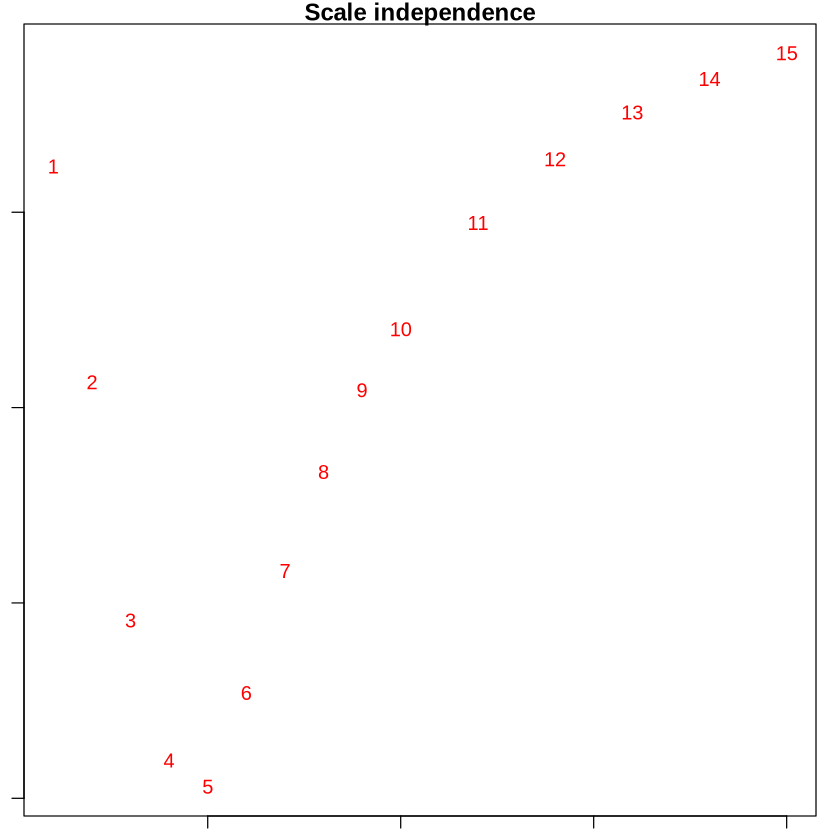

In [ ]:
# Start PNG device
# png("plot_r2_softthreshold.png", width = 600, height = 800, res = 900)

par(mar=c(1,1,1,1))
plot(spt$fitIndices[,1],spt$fitIndices[,2],
xlab="Soft Threshold (power)",ylab="Scale Free Topology Model Fit,signed R^2",type="n",
main = paste("Scale independence"))
text(spt$fitIndices[,1],spt$fitIndices[,2],col="red")
abline(h=0.80,col="red")

# dev.off()

In [ ]:
# Plot mean connectivity as a function of soft thresholds

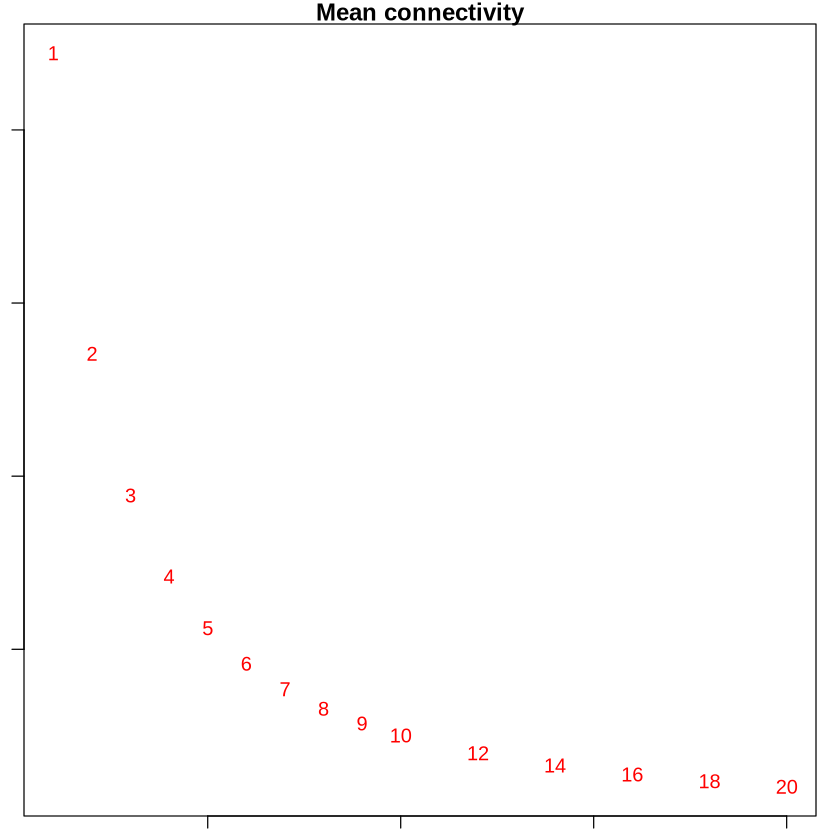

In [ ]:
# Start PNG device
# png("plot_mean_connectivity_softthreshold.png", width = 600, height = 800, res = 900)

par(mar=c(1,1,1,1))
plot(spt$fitIndices[,1], spt$fitIndices[,5],
xlab="Soft Threshold (power)",ylab="Mean Connectivity", type="n",
main = paste("Mean connectivity"))
text(spt$fitIndices[,1], spt$fitIndices[,5], labels= spt$fitIndices[,1],col="red")


In [ ]:
# You can determine the soft power threshold should be set to 6 as it is the spt that retains the highest mean connectivity while reaching an 𝑅2 value above 0.80.

Calling the Adjacency Function

In [ ]:
softPower <- 20
adjacency <- adjacency(expression.data, power = softPower, type = "signed", corFnc = "cor")

In [ ]:
head(adjacency)

,GSTM1,CARTPT,MIR3976HG,LINC02263,PVALB,LINC00507,LINC01164,CTXN3,ROS1,SLC27A6,⋯,UNC5C,NRF1,AP2A2,SPPL2A,C14orf93,ENAH,ADAM10,RERE,WDR12,HP1BP3
GSTM1,1.000000e+00,5.045212e-13,1.903733e-05,9.432445e-07,1.034510e-05,1.123529e-09,2.504145e-05,3.879424e-09,3.751519e-07,1.524831e-06,⋯,3.178686e-08,3.451406e-03,6.108605e-04,2.214353e-09,4.556577e-04,3.804616e-17,6.845907e-12,4.129392e-04,1.546072e-08,2.351577e-06
CARTPT,5.045212e-13,1.000000e+00,4.135277e-09,6.140359e-06,2.009001e-06,3.530887e-04,1.075067e-05,6.658660e-04,1.402935e-04,2.297567e-15,⋯,1.400887e-08,7.277801e-07,3.549098e-07,1.044662e-03,2.426320e-09,1.619500e-03,7.493201e-06,1.202970e-05,3.860181e-08,1.724622e-06
MIR3976HG,1.903733e-05,4.135277e-09,1.000000e+00,4.448904e-02,2.313024e-02,1.251768e-01,2.740533e-04,3.498268e-03,1.716751e-01,2.645072e-08,⋯,8.207783e-09,9.166184e-12,1.148339e-04,8.032314e-22,1.873755e-16,2.356432e-13,2.080748e-15,1.214461e-04,4.802344e-03,3.586307e-21
LINC02263,9.432445e-07,6.140359e-06,4.448904e-02,1.000000e+00,1.240376e-02,3.970830e-02,3.985833e-05,1.467539e-02,1.281681e-01,2.244934e-11,⋯,1.628717e-06,1.350047e-10,2.343169e-05,5.612673e-14,5.346667e-13,8.389893e-08,9.805323e-11,1.409309e-07,6.773866e-03,1.015433e-13
PVALB,1.034510e-05,2.009001e-06,2.313024e-02,1.240376e-02,1.000000e+00,1.655442e-02,1.425293e-05,2.737721e-01,1.257616e-01,2.175064e-07,⋯,4.804805e-05,3.918106e-05,6.874791e-07,4.637158e-24,8.115460e-21,3.261310e-14,8.174309e-11,1.057510e-03,1.590316e-01,1.358384e-17
LINC00507,1.123529e-09,3.530887e-04,1.251768e-01,3.970830e-02,1.655442e-02,1.000000e+00,1.804916e-03,7.552310e-02,4.260441e-01,5.123686e-13,⋯,2.472403e-08,2.355212e-12,1.792240e-06,9.440904e-14,1.650224e-21,7.093388e-08,9.897082e-11,3.502090e-05,3.572874e-03,3.297632e-17


In [ ]:
# Convert the adjacency matrix to a vector (excluding the diagonal if necessary)
adjacency_vector <- as.vector(adjacency)
if (isTRUE(all.equal(diag(adjacency), rep(1, nrow(adjacency))))) {
    adjacency_vector <- adjacency_vector[-which(row(adjacency) == col(adjacency))]
}

# Calculate the percentage of values greater than 0.5
percentage_over_0_5 <- sum(adjacency_vector > 0.5) / length(adjacency_vector) * 100

# Print the percentage
print(paste("Percentage of gene connections with values > 0.5:", percentage_over_0_5, "%"))


[1] "Percentage of gene connections with values > 0.5: 0.30892 %"


In [ ]:
# Flatten the matrix to a vector, excluding the diagonal
weights <- as.vector(adjacency[upper.tri(adjacency)])

# Sort the weights in increasing order to find the correct threshold for top 0.5%
sorted_weights <- sort(weights, decreasing = FALSE)

# Determine the 0.5th percentile position (the top 0.5% weights)
threshold_index <- ceiling(0.9949 * length(sorted_weights))
threshold_value <- sorted_weights[threshold_index]
print(threshold_value)

# Apply this threshold to the adjacency matrix to create a new binary matrix
binary_adjacency_matrix <- adjacency > threshold_value
binary_adjacency_matrix <- 1 * binary_adjacency_matrix

# Keep the row and column names
rownames(binary_adjacency_matrix) <- rownames(adjacency)
colnames(binary_adjacency_matrix) <- colnames(adjacency)


[1] 0.4051954


In [ ]:
# Calculate the number of edges above the threshold
num_edges <- sum(binary_adjacency_matrix[upper.tri(binary_adjacency_matrix)])

# Calculate the total possible number of edges
num_possible_edges <- choose(nrow(adjacency), 2)

# Calculate edge density
actual_edge_density <- num_edges / num_possible_edges

# Print edge density
print(paste("The edge density of the network is:", actual_edge_density * 100, "%"))


[1] "The edge density of the network is: 0.50999799959992 %"


In [ ]:
write.csv(binary_adjacency_matrix, "adj_mat_9_4.csv", row.names = TRUE)

## 2. Identifying intermediate genes (Shortest paths) and filtering the matrices

A modified code to limit the number of intermediates by 2*SHAP*GWAS for clusters

In [38]:
# For all adjacency matrices

import pandas as pd
import igraph as ig
import os
import glob
import ast

# Load the summary file with gene lists for each cluster
summary_df = pd.read_csv('./summary_shap_gwas_sep_8.csv')

# Path to the directory containing the adjacency matrices
path = './adjacency_matrix/rnaseq_synapse/'

# Prepare a DataFrame to store the results
results_df = pd.DataFrame()

# Loop over all adjacency matrix files
for file_path in glob.glob(path + 'adj_mat_*.csv'):
    cluster_number = os.path.basename(file_path).replace('adj_mat_', '').split('.')[0]
    df = pd.read_csv(file_path, index_col=0)
    g = ig.Graph.Adjacency((df.values > 0).tolist(), mode=ig.ADJ_UNDIRECTED)
    g.vs['name'] = df.columns.tolist()

    current_cluster_info = summary_df[summary_df['Cluster'] == cluster_number].iloc[0]
    shap_genes = ast.literal_eval(current_cluster_info['Common SHAP Genes'])
    gwas_genes = ast.literal_eval(current_cluster_info['GWAS Genes'])

    shap_genes = [gene for gene in shap_genes if gene in g.vs['name']]
    gwas_genes = [gene for gene in gwas_genes if gene in g.vs['name']]

    max_allowed_intermediates = 2 * len(shap_genes) * len(gwas_genes)

    intermediate_counts_by_path_length = {}
    cumulative_intermediates = set()
    suitable_threshold = None

    for shap_gene in shap_genes:
        for gwas_gene in gwas_genes:
            try:
                start_vertex = g.vs.find(name=shap_gene).index
                end_vertex = g.vs.find(name=gwas_gene).index
                path = g.get_shortest_paths(start_vertex, to=end_vertex, output="vpath")[0]
                path_length = len(path) - 2  # Subtracting start and end nodes
                if path_length > 0:
                    intermediates = [g.vs[vertex_id]['name'] for vertex_id in path[1:-1]]
                    if path_length not in intermediate_counts_by_path_length:
                        intermediate_counts_by_path_length[path_length] = set(intermediates)
                    else:
                        intermediate_counts_by_path_length[path_length].update(intermediates)
            except ValueError:
                continue  # Skip if gene not found in the network

    # Determine the suitable threshold based on the maximum allowed intermediates
    for length in sorted(intermediate_counts_by_path_length):
        cumulative_intermediates.update(intermediate_counts_by_path_length[length])
        if len(cumulative_intermediates) > max_allowed_intermediates and suitable_threshold is None:
            suitable_threshold = length - 1

    if suitable_threshold is None:
        suitable_threshold = max(intermediate_counts_by_path_length.keys(), default=0)

    # Calculate the count of intermediates only up to the suitable threshold
    final_intermediates = set()
    for length in sorted(intermediate_counts_by_path_length):
        if length <= suitable_threshold:
            final_intermediates.update(intermediate_counts_by_path_length[length])

    # Store the results in a new row
    new_row = pd.DataFrame({
        'Cluster': [cluster_number],
        'Total Unique Intermediates': [len(final_intermediates)],
        'Unique Intermediates List': [list(final_intermediates)],
        'Threshold': [suitable_threshold],
        'Maximum Allowed Intermediates': [max_allowed_intermediates]
    })

    # Concatenate the new row with the results DataFrame
    results_df = pd.concat([results_df, new_row], ignore_index=True)

/tmp/ipykernel_24112/4269935689.py:41: RuntimeWarning: Couldn't reach some vertices at src/paths/unweighted.c:444
  path = g.get_shortest_paths(start_vertex, to=end_vertex, output="vpath")[0]
/tmp/ipykernel_24112/4269935689.py:41: RuntimeWarning: Couldn't reach some vertices at src/paths/unweighted.c:444
  path = g.get_shortest_paths(start_vertex, to=end_vertex, output="vpath")[0]
/tmp/ipykernel_24112/4269935689.py:41: RuntimeWarning: Couldn't reach some vertices at src/paths/unweighted.c:444
  path = g.get_shortest_paths(start_vertex, to=end_vertex, output="vpath")[0]
/tmp/ipykernel_24112/4269935689.py:41: RuntimeWarning: Couldn't reach some vertices at src/paths/unweighted.c:444
  path = g.get_shortest_paths(start_vertex, to=end_vertex, output="vpath")[0]
/tmp/ipykernel_24112/4269935689.py:41: RuntimeWarning: Couldn't reach some vertices at src/paths/unweighted.c:444
  path = g.get_shortest_paths(start_vertex, to=end_vertex, output="vpath")[0]
/tmp/ipykernel_24112/4269935689.py:41: R

In [42]:

# Get the list of genes from the first row of the 'Unique Intermediates List' column
gene_list = results_df.loc[1, 'Unique Intermediates List']

# Print the list of genes
print("List of genes:", gene_list)

# Print the number of elements in the list
print("Number of elements in the list:", len(gene_list))

List of genes: ['GALNT7', 'GBP1', 'SLC9A2', 'RPS2', 'RGS8', 'HPCA', 'PRICKLE1', 'PRLR', 'RIN1', 'MT-ND3', 'GRM2', 'STAT4', 'KCNAB3', 'LOC441239', 'ADA', 'GTF2IRD2', 'TC2N', 'FILIP1', 'CHN1', 'DPP3-DT', 'CRABP2', 'FSCN2', 'C8orf34-AS1', 'RAB3C', 'PROCR', 'PTGDR2', 'KCNQ1', 'PLCH2', 'AP1G2', 'FBXO5', 'DRD2', 'UNC13C', 'NCF2', 'SMPX', 'LILRB3', 'HEYL', 'LRRTM4', 'TMC2', 'SEMA3D', 'SPEG', 'SERPINE1', 'C9orf50', 'HHEX', 'FBXL2', 'BAAT', 'CD37', 'IL13RA2', 'LINC01299', 'SKAP2', 'MUC1', 'CD8B2', 'VIRMA-DT', 'SLC8A3', 'UAP1L1', 'CMTM7', 'PCDH7', 'IGF2BP2', 'SLC39A12', 'NAALADL1', 'DPP10-AS1', 'ALOXE3', 'KIAA2012', 'LINC00507', 'DIO3OS', 'NPIPA5', 'COL15A1', 'ZP3', 'ATP10A', 'PPFIA3', 'GAB3', 'MAP1B', 'MTUS1', 'PCDH11Y', 'CHAD', 'TSPAN18', 'RPRML', 'GPR146', 'NREP', 'INPP5D', 'CA14', 'STEAP2', 'CAMK2A', 'STS', 'LINC00940', 'PHOSPHO1', 'MSC-AS1', 'RALY-AS1', 'PDZRN3', 'APOE', 'AACS', 'LANCL3', 'ECE2', 'SETBP1', 'LINC03022', 'KIF26A', 'ULK1', 'CFAP251', 'OPRM1', 'CRHR2', 'MIR3976HG', 'TRGC2', 'RA

In [43]:
results_df.to_csv("intermediate_genes_network_sep19.csv")

Limit the number of intermediate genes per path

Modify the summary file and add these details

In [ ]:
import pandas as pd
summary_df = pd.read_csv("./summary_shap_gwas_sep_8.csv")
summary_df

In [45]:
# Assuming 'df' is your DataFrame and you want to drop 'Column1' and 'Column2'
results_df.drop(['Threshold', 'Maximum Allowed Intermediates'], axis=1, inplace=True)
results_df

,Cluster,Total Unique Intermediates,Unique Intermediates List
0,4_4,331,"[ATG9B, FGF5, PTPRT, PTPN6, KHDRBS2, CEDORA, M..."
1,1_1,2583,"[GALNT7, GBP1, SLC9A2, RPS2, RGS8, HPCA, PRICK..."
2,7_3,304,"[ST18, TMEM47, IL18R1, CDCA7, ERBB3, PCDH11X, ..."
3,5_3,63,"[FBXL16, NOTCH2, NFIC, WWTR1, BGN, TMEM47, OBS..."
4,7_1,43,"[OBSCN, EFR3A, RIMS3, RET, ACHE, PODXL2, PLCB2..."
5,8_2,55,"[AMIGO2, SNX10-AS1, S1PR3, LIFR, OBSCN, DTX3L,..."
6,5_2,89,"[CPVL, SELENOP, TP53I11, SLC12A5, WWTR1, SIGLE..."
7,1_3,631,"[APP, GALNT12, ANTKMT, NDRG1, RGS8, ANO6, MAN1..."
8,9_4,1128,"[GBP1, IL1RAPL2, RGS8, ERBB3, GIMAP2, MAN1A1, ..."
9,2_3,460,"[SAMD11, SIGLEC14, ARSL, PTPRT, LINC02610, PTP..."


In [ ]:
# Merging the DataFrames on 'Cluster' column
merged_df = pd.merge(summary_df, results_df, on='Cluster', how='left')
merged_df

In [47]:
merged_df.to_csv('summary_shap_gwas_intermediates_final.csv')

Filtering the adjacency matrices

Code for filtering all adjacency matrices

In [14]:
import pandas as pd
import os
import ast
import glob

# Load the summary file
summary_df = pd.read_csv("summary_shap_gwas_intermediates_final.csv", index_col=0)

# Path to the directory containing the adjacency matrices
path = './adjacency_matrix/rnaseq_synapse/'

# New directory to save the filtered matrices
new_path = './adjacency_matrix/filtered_adj_matrices/'
os.makedirs(new_path, exist_ok=True)

# Loop over all adjacency matrix files
for file_path in glob.glob(os.path.join(path, 'adj_mat_*.csv')):
    cluster_number = os.path.basename(file_path).replace('adj_mat_', '').replace('.csv', '')

    # Retrieve the gene lists for the current cluster from the summary DataFrame
    if cluster_number in summary_df['Cluster'].values:
        cluster_data = summary_df[summary_df['Cluster'] == cluster_number].iloc[0]
        
        # Load the adjacency matrix for the specified cluster
        adj_matrix = pd.read_csv(file_path, index_col=0)

        # Parse gene lists from the cluster data
        shap_genes = ast.literal_eval(cluster_data['Common SHAP Genes'])
        gwas_genes = ast.literal_eval(cluster_data['GWAS Genes'])
        intermediate_genes = ast.literal_eval(cluster_data['Unique Intermediates List'])

        # Create a set of all relevant genes (union of SHAP, GWAS, and intermediates)
        all_relevant_genes = set(shap_genes + gwas_genes + intermediate_genes)

        # Filter the adjacency matrix to only include relevant genes in rows and columns
        filtered_adj_matrix = adj_matrix.loc[
            adj_matrix.index.intersection(all_relevant_genes),
            adj_matrix.columns.intersection(all_relevant_genes)
        ]

        # Save the filtered adjacency matrix
        filtered_file_path = os.path.join(new_path, f'adj_mat_{cluster_number}_filt.csv')
        filtered_adj_matrix.to_csv(filtered_file_path)
    else:
        print(f"No data for cluster {cluster_number} found in summary.")


## 3. Identification of Hub genes in adjancency matrix by network metrics

### 1. Process All Clusters and Record the Results

complete code parralized (step 1 and 2)

In [29]:
import pandas as pd
import networkx as nx
import os
from concurrent.futures import ProcessPoolExecutor, as_completed

# Path to the directory where the adjacency matrices are stored
matrix_directory = '~/rnaseq_synapse/adjacency_matrix/filtered_adj_matrices/'

# Function to calculate metrics and find top 5 genes per metric
def calculate_metrics_for_cluster(cluster):
    file_name = f'adj_mat_{cluster}_filt.csv'
    file_path = os.path.join(matrix_directory, file_name)
    
    # Step 1: Read the adjacency matrix
    adjacency_matrix = pd.read_csv(file_path, index_col=0)
    G = nx.from_pandas_adjacency(adjacency_matrix)
    
    # Step 2: Calculate all centrality metrics
    degree_centrality = nx.degree_centrality(G)
    betweenness_centrality = nx.betweenness_centrality(G)
    closeness_centrality = nx.closeness_centrality(G)
    eigenvector_centrality = nx.eigenvector_centrality(G, max_iter=1000)
    pagerank = nx.pagerank(G)
    clustering_coefficient = nx.clustering(G)

    # Step 3: Combine all metrics into a DataFrame
    metrics_df = pd.DataFrame({
        'degree': degree_centrality,
        'betweenness': betweenness_centrality,
        'closeness': closeness_centrality,
        'eigenvector': eigenvector_centrality,
        'pagerank': pagerank,
        'clustering_coefficient': clustering_coefficient
    })
    
    # Step 4: Find top 5 genes per metric
    top_n = 5
    top_genes = {}
    for metric in metrics_df.columns:
        if metric == 'clustering_coefficient':
            top_genes[metric] = metrics_df.nsmallest(top_n, metric).index.tolist()
        else:
            top_genes[metric] = metrics_df.nlargest(top_n, metric).index.tolist()
    
    return cluster, metrics_df, top_genes

# Function to parallelize cluster processing using ProcessPoolExecutor
def parallel_process_clusters(cluster_hub_genes, max_workers=4):
    all_metrics_df = {}
    all_top_genes = {}
    
    # Using ProcessPoolExecutor to parallelize the processing of each cluster
    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        # Submit tasks to process each cluster in parallel
        futures = {executor.submit(calculate_metrics_for_cluster, cluster): cluster for cluster in cluster_hub_genes.keys()}
        
        for future in as_completed(futures):
            cluster, metrics_df, top_genes = future.result()
            all_metrics_df[cluster] = metrics_df  # Store the DataFrame for this cluster
            all_top_genes[cluster] = top_genes    # Store the top genes for this cluster

    return all_metrics_df, all_top_genes

# Run the parallel processing with 4 workers
all_metrics_df, all_top_genes = parallel_process_clusters(cluster_hub_genes, max_workers=10)

# Example output:
# all_metrics_df['1_1'] gives the metrics DataFrame for cluster '1_1'
# all_top_genes['1_1'] gives the top genes for each metric in cluster '1_1'


In [68]:
all_top_genes['9_4']

{'degree': ['ADRA2C', 'AHNAK', 'ROS1', 'HCN1', 'EPHX1'],
 'betweenness': ['RTN4R', 'LRRTM1', 'NPTX1', 'SHC3', 'AP2A2'],
 'closeness': ['ADRA2C', 'RAVER2', 'TNFRSF1B', 'PTPRZ1', 'PARD3'],
 'eigenvector': ['ROS1', 'TESPA1', 'GABRG2', 'TTC23-AS1', 'PDP1'],
 'pagerank': ['FCER1G', 'EPHX1', 'FAM107B', 'ADRA2C', 'HCN1'],
 'clustering_coefficient': ['MET', 'NGB', 'ADAMTS2', 'FIBCD1', 'SLC47A2']}

In [31]:
# save the two dictionaries

import pickle

# Path to save the pickle files
pickle_dir = '/home/vmottaqi/rnaseq_synapse'  # Change this to your desired directory

# Save the all_metrics_df dictionary to a pickle file
with open(f'{pickle_dir}/clusters_all_metrics_df.pkl', 'wb') as metrics_file:
    pickle.dump(all_metrics_df, metrics_file)

# Save the all_top_genes dictionary to a pickle file
with open(f'{pickle_dir}/clusters_all_top_genes_df.pkl', 'wb') as top_genes_file:
    pickle.dump(all_top_genes, top_genes_file)

print("Dictionaries have been saved in pickle format.")


Dictionaries have been saved in pickle format.


### 2. Compare Top Genes with Pubmed Hub Genes and Identify Higher Ranked Genes (Novel targets)

I have the pubmed top genes per cluster now (the following dictionary)

In [ ]:
cluster_hub_genes = {
    '1_1': ['EGF', 'PTPRC', 'ECHDC3', 'NEFL'],
    '1_2': ['CXCL16', 'SPOCK3'],
    '1_3': ['C1S', 'CPT1A'],
    '1_4': ['HGF', 'SCN2A'],
    '2_1': ['FLT4'],
    '2_2': ['C4B', 'GRIN2A', 'NEUROD1'],
    '2_3': ['APOC1', 'RORA', 'AP2A2'],
    '3_1': ['APP', 'GRIN2A', 'INA'],
    '3_2': ['FABP7', 'GPR158', 'FGF14'],
    '3_3': ['APOC1', 'APP', 'LPL', 'PLXNA4', 'PRKCE'],
    '3_4': ['NAPB', 'TNFRSF21', 'STXBP1'],
    '4_1': ['MS4A6A', 'RYR3'],
    '4_2': ['EGF', 'IL33', 'MS4A6A', 'VGF'],
    '4_3': ['CNTNAP5-DT', 'NOTCH1'],
    '4_4': ['INA', 'LAMP2'],
    '5_1': ['CSF1', 'SOX10', 'LRP10'],
    '5_2': ['HSPA2', 'MAG'],
    '5_3': ['PFKFB3', 'TMEM106B', 'ERBB2'],
    '5_4': ['IKZF1', 'MS4A6A'],
    '6_1': ['ACE', 'STMN2'],
    '6_2': ['GPR6', 'HCK', 'UCP2'],
    '6_3': ['INA', 'PLXNA4', 'TGFB1'],
    '6_4': ['CASP8', 'CLSTN3', 'MAL'],
    '7_1': ['ACE', 'ACHE', 'CR1', 'LTF', 'SERPINI1', 'FLNA'],
    '7_2': ['BIN1'],
    '7_3': ['ITPKB', 'PCDH11X', 'TF'],
    '7_4': ['PLXNB1', 'APLNR'],
    '8_1': ['MEGF10', 'PLXNA1', 'STX1B'],
    '8_2': ['ANGPT1', 'FGF1'],
    '8_3': ['CPLX2', 'UNC13A'],
    '8_4': ['MME', 'SLC17A6'],
    '9_1': ['INPP5D', 'KLK6', 'SYT4'],
    '9_2': ['CAMK2A', 'SLC24A4', 'SPI1'],
    '9_3': ['AP2A2', 'INPP5D'],
    '9_4': ['AP2A2', 'NPTX1', 'MET', 'FCER1G', 'HCN1']
}


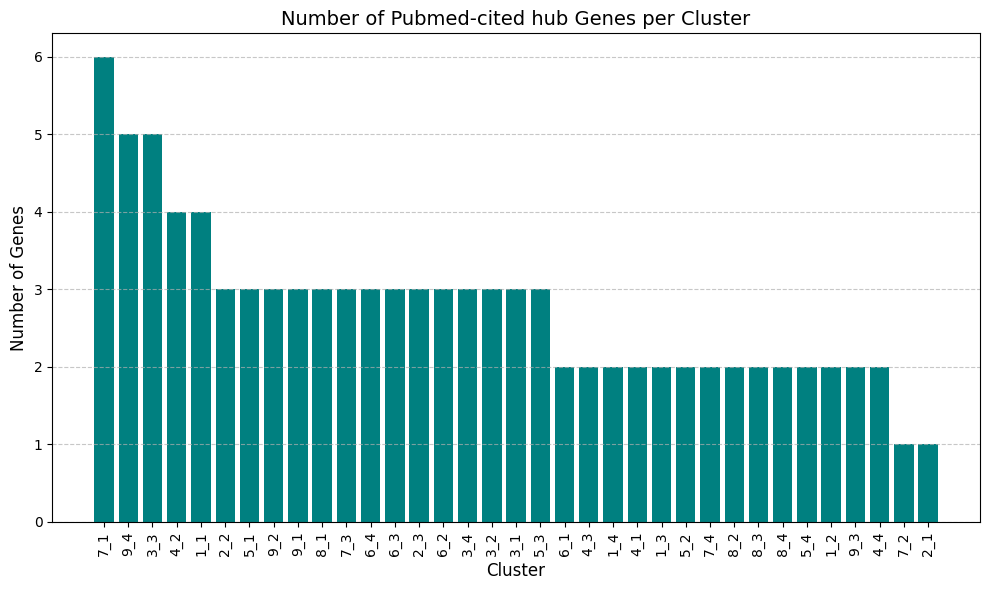

In [ ]:
# Histogram

import matplotlib.pyplot as plt
import pandas as pd

# Calculate the number of genes per cluster
gene_counts = {cluster: len(genes) for cluster, genes in cluster_hub_genes.items()}

# Convert the dictionary to a DataFrame for easier manipulation
df_gene_counts = pd.DataFrame(list(gene_counts.items()), columns=['Cluster', 'Gene_Count'])

# Sort the DataFrame by the number of genes in descending order
df_gene_counts = df_gene_counts.sort_values(by='Gene_Count', ascending=False)

# Plot the histogram
plt.figure(figsize=(10, 6))
plt.bar(df_gene_counts['Cluster'], df_gene_counts['Gene_Count'], color='teal')

# Add labels and title
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Number of Genes', fontsize=12)
plt.title('Number of Pubmed-cited hub Genes per Cluster', fontsize=14)
plt.xticks(rotation=90)  # Rotate x-axis labels for readability

# Add gridlines for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()  # Adjusts the layout so everything fits
plt.savefig("/home/vmottaqi/rnaseq_synapse/figures/pubmed_hub_genes_by_cluster_oct8_2024.png", dpi=1000)
plt.show()


In [70]:
# Function to find the rank of a gene in a specific metric
def find_gene_rank(metrics_df, gene, metric):
    sorted_genes = metrics_df[metric].rank(ascending=False)
    return sorted_genes[gene] if gene in sorted_genes else None

# Store the genes with higher ranks than the hub genes for each cluster
higher_ranked_genes_by_cluster = {}

# For each cluster, compare the hub genes with the top genes in the calculated metrics
for cluster, hub_genes in cluster_hub_genes.items():
    higher_ranked_genes_by_cluster[cluster] = []
    
    # Get the metrics DataFrame and top genes for this cluster
    metrics_df = all_metrics_df[cluster]
    top_genes = all_top_genes[cluster]
    
    # Dictionary to store the highest (i.e., lowest rank number) rank among hub genes for each metric
    highest_hub_gene_rank = {metric: float('inf') for metric in metrics_df.columns}
    
    # Step 1: Find the highest rank for each metric considering all hub genes
    for hub_gene in hub_genes:
        for metric in metrics_df.columns:
            hub_gene_rank = find_gene_rank(metrics_df, hub_gene, metric)
            if hub_gene_rank and hub_gene_rank < highest_hub_gene_rank[metric]:
                highest_hub_gene_rank[metric] = hub_gene_rank
    
    # Step 2: Compare against the top genes for each metric
    for metric, top_gene_list in top_genes.items():
        for top_gene in top_gene_list:
            top_gene_rank = find_gene_rank(metrics_df, top_gene, metric)
            
            # If the top gene has a higher rank (lower rank number) than the best hub gene rank, store it
            if top_gene_rank and top_gene_rank < highest_hub_gene_rank[metric]:
                higher_ranked_genes_by_cluster[cluster].append((top_gene, top_gene_rank, metric))

# Example output:
# higher_ranked_genes_by_cluster['1_1'] gives all top-ranked genes that are ranked higher than the hub genes for cluster '1_1'


In [53]:
higher_ranked_genes_by_cluster['3_3']

[('KIAA1549L', 1.0, 'degree'),
 ('STX1B', 1.0, 'betweenness'),
 ('IL1RAP', 2.0, 'betweenness'),
 ('PGAP4', 3.0, 'betweenness'),
 ('KIAA1549L', 1.0, 'eigenvector'),
 ('DCLK1', 1.0, 'pagerank')]

Save the Dictionary as a Pickle File

In [71]:
import pickle
import os

# Path to save the pickle file
pickle_dir = os.path.expanduser('/home/vmottaqi/rnaseq_synapse')

# Ensure the directory exists
if not os.path.exists(pickle_dir):
    os.makedirs(pickle_dir)

# Save the higher_ranked_genes_by_cluster dictionary to a pickle file
with open(f'{pickle_dir}/novel_hub_genes_by_cluster.pkl', 'wb') as file:
    pickle.dump(higher_ranked_genes_by_cluster, file)

print("The dictionary has been saved in pickle format.")


The dictionary has been saved in pickle format.


### 3. Obtaining files to import to Gephi for network visualizations

In [11]:
adjacency_df = pd.read_csv("~/rnaseq_synapse/adjacency_matrix/rnaseq_synapse/adj_mat_5_3.csv", index_col=0)
adjacency_df

,GSTM1,CARTPT,MIR3976HG,LINC02263,PVALB,LINC00507,LINC01164,CTXN3,ROS1,SLC27A6,...,UNC5C,NRF1,AP2A2,SPPL2A,C14orf93,ENAH,ADAM10,RERE,WDR12,HP1BP3
GSTM1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
CARTPT,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
MIR3976HG,0,0,1,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
LINC02263,0,0,0,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
PVALB,0,0,1,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENAH,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,0
ADAM10,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
RERE,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
WDR12,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [12]:
# Unstack the adjacency matrix to create a long format DataFrame
edges = adjacency_df.unstack().reset_index()
edges.columns = ['Source', 'Target', 'Connection']

# Filter out rows where there is no edge
edges = edges[edges['Connection'] == 1]

# Remove self-loops
edges = edges[edges['Source'] != edges['Target']]

# Drop the Connection column as it's no longer needed
edges = edges.drop(columns=['Connection'])

# Remove duplicates
edges = edges.drop_duplicates()

In [13]:
edges

,Source,Target
10116,MIR3976HG,PVALB
10120,MIR3976HG,ROS1
10124,MIR3976HG,LINC00898
10154,MIR3976HG,EPIC1
10171,MIR3976HG,KCNS1
...,...,...
25558015,WDR12,STRBP
25558900,HP1BP3,IP6K3
25559346,HP1BP3,KCNJ2
25561868,HP1BP3,LDLRAP1


In [14]:
# Replace 'path_to_attribute_file.csv' with your actual file path
attributes_df = pd.read_csv('~/rnaseq_synapse/summary_shap_gwas_intermediates_final.csv')

# Extract rows where 'Cluster' column is '5_1'
filtered_attributes = attributes_df[attributes_df['Cluster'] == '5_3']
filtered_attributes

,Unnamed: 0,Cluster,Study,Samples in Cluster,Unique Individuals,Common SHAP Genes Count,Common SHAP Genes,Individuals_gwas,GWAS snps count,GWAS snps,GWAS Genes,GWAS Genes Count,Total Unique Intermediates,Unique Intermediates List
18,18,5_3,MSBB,38,35,11,"['NWD1', 'NPNT', 'PIRT', 'ITPKB', 'SLC6A9', 'S...",36,20,"['rs3753275', 'rs6846414', 'rs6460901', 'rs317...","['RERE', 'CDH23', 'ZNF423', 'DSG2', 'NME8', 'T...",7,63.0,"['FBXL16', 'NOTCH2', 'NFIC', 'WWTR1', 'BGN', '..."


In [15]:
# modified

import ast

# Create a DataFrame for nodes
nodes = pd.DataFrame(adjacency_df.columns, columns=['Id'])

# Preprocess attributes DataFrame to convert string representations of lists to actual lists
def convert_to_list(string):
    try:
        return ast.literal_eval(string)
    except ValueError:
        return []

# Apply the conversion to each relevant column
filtered_attributes['GWAS Genes'] = filtered_attributes['GWAS Genes'].apply(convert_to_list)
filtered_attributes['Common SHAP Genes'] = filtered_attributes['Common SHAP Genes'].apply(convert_to_list)
filtered_attributes['Unique Intermediates List'] = filtered_attributes['Unique Intermediates List'].apply(convert_to_list)

# Define a function to determine the attribute of each node
def determine_attribute(node, attributes):
    if node in attributes['GWAS Genes'].iloc[0]:
        return 'GWAS'
    elif node in attributes['Common SHAP Genes'].iloc[0]:
        return 'SHAP'
    elif node in attributes['Unique Intermediates List'].iloc[0]:
        return 'Intermediate'
    else:
        return 'Rest'

# Apply the function to each node
nodes['Attribute'] = nodes['Id'].apply(lambda x: determine_attribute(x, filtered_attributes))
nodes


/tmp/ipykernel_35985/2221958481.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_attributes['GWAS Genes'] = filtered_attributes['GWAS Genes'].apply(convert_to_list)
/tmp/ipykernel_35985/2221958481.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_attributes['Common SHAP Genes'] = filtered_attributes['Common SHAP Genes'].apply(convert_to_list)
/tmp/ipykernel_35985/2221958481.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .

,Id,Attribute
0,GSTM1,Rest
1,CARTPT,Rest
2,MIR3976HG,Rest
3,LINC02263,Rest
4,PVALB,Rest
...,...,...
5051,ENAH,Rest
5052,ADAM10,Rest
5053,RERE,GWAS
5054,WDR12,Rest


In [18]:
# Count the number of rows for each unique value in the 'Attribute' column
attribute_counts = nodes['Attribute'].value_counts()

# Print the counts
print(attribute_counts)

Attribute
Rest            4978
Intermediate      63
SHAP              11
GWAS               4
Name: count, dtype: int64


In [10]:
edges.to_excel('edges_5_3_for_gephi_oct13.xlsx', index=False)
nodes.to_excel('nodes_5_3_for_gephi_oct13.xlsx', index=False)

# Repurpusing drugs which target critical bottleneck genes through Bioteque KG

## 1. Extracting info from four embedding spaces/Metapaths

In [16]:
# Union of the novel hub genes

import pickle
import os

# Load the dictionary from the pickle file
pickle_dir = os.path.expanduser('~/rnaseq_synapse')
with open(f'{pickle_dir}/novel_hub_genes_by_cluster.pkl', 'rb') as file:
    higher_ranked_genes_by_cluster = pickle.load(file)



# Get the union of all genes from the higher_ranked_genes_by_cluster dictionary
genes_interest = set()

# Iterate through each cluster and collect all genes
for cluster, gene_info in higher_ranked_genes_by_cluster.items():
    for gene, rank, metric in gene_info:
        genes_interest.add(gene)



In [17]:
for i in genes_interest:
    print(i)

PLXNB1
LRMDA
SMPX
SLC44A1
AMZ1
LIFR
EPS8
SYNGR2
VRK2
PDK4
LINC03122
SPEG
ATP2B3
NEFH
GNMT
ADRA2C
ARAP2
ARHGAP39
ADAM12
GPR22
P2RX5-TAX1BP3
LOC107984948
GABRG2
DLC1
SLC9A5
GNG2
CP
KLF16
TEX29
SLC45A3
C1orf198
DCAF12L2
NRSN2
SOX2-OT
SLC4A10
CHST3
TNC
PDLIM5
MLH3
GPR37
LNX1
ABCG4
ST18
KCNS3
NRF1
ZYX
VWA5B2
SULT4A1
ATOH8
BASP1
FLI1
PRDM16-DT
COL8A1
FENDRR
ABTB3
ECHDC2
PTPRZ1
ITGB4
PARD3
CYGB
TNFRSF25
CHGA
NEFM
NRG4
MS4A4A
EDIL3
AP3B2
ZBTB8B
CYBA
MLLT11
SCN8A
LINC00320
GABRB2
ANO6
MKX
CDH19
SELL
PSMC3
NFIC
MIR3667HG
KCNQ5
TTC23-AS1
BEST1
CDH23
EMILIN3
STX1B
HBEGF
CRNDE
FRMPD4
PLP1
PRR18
PTTG1IP
IQGAP1
PDP1
LINC00877
RAB3A
DCDC1
KCNV1
ADGRL1-AS1
STON2
PKD1P3
UGT8
LOC107986669
FGF1
FGF12
FOLH1
CNTNAP2
KALRN
TMEM144
TSPAN12
GABRA3
ABCA8
PGM5
B2M
NRXN1
HEPACAM
CBR3
RPS18P5
SATB2-AS1
PODXL2
CERCAM
ZCCHC24
NWD2
SOHLH1
CACNG8
TESPA1
KCNN1
MAP1B
ZNF837
PAK1
RIMS3
STXBP1
GNG12
NOTCH1
TMEM63A
LRRTM1
TNFRSF1B
HSPB8
NFATC4
CPNE9
ITGA2
CHGB
LENG9
KCNC2
MAP3K9
DNAI4
ROS1
GABRQ
WWTR1
SBNO2
DDIT4
ALDH1L1
E

This process repeated was repeated for each of the four metaphats.
the output dfs were saved and then concatenated with a unix command.

In [62]:
import pandas as pd
embeddings = pd.read_csv('/home/vmottaqi/rnaseq_synapse/Bioteque/CPD-int-GEN-ppi-GEN/curated_targets-string/embeddings/dists.tsv', sep='\t')
compounds = pd.read_csv('/home/vmottaqi/rnaseq_synapse/Bioteque/CPD.tsv', sep='\t')
genes = pd.read_csv('/home/vmottaqi/rnaseq_synapse/Bioteque/GEN.tsv', sep='\t')

In [64]:
# Map compounds and genes to their names
embeddings = embeddings.merge(compounds, left_on='n1_CPD', right_on='code', how='left')
embeddings = embeddings.merge(genes, left_on='n2_GEN', right_on='code', how='left')
# Rename columns for clarity
embeddings.rename(columns={'name_x': 'compound_name', 'name_y': 'gene_name'}, inplace=True)
embeddings.head(3)

,n1_CPD,n2_GEN,cosine_distance,code_x,compound_name,mw,ro5,qed,embedding_universe_x,code_y,gene_name,geneid,ensemble,desc,embedding_universe_y
0,AAAQFGUYHFJNHI-SFHVURJKSA-N,A0AVK6,0.5572,AAAQFGUYHFJNHI-SFHVURJKSA-N,GSK 525762A,423.9,0.0,0.462,"(CHE-has-CPD,chebi);(CLL-sns-CPD,ctrpv2_sens);...",A0AVK6,E2F8,79733,ENSG00000129173,"Transcription factor E2F8, E2F-8","(CLL-dwr+upr-GEN-dwr+upr-CLL-bfn-PGN-pdw-GEN,c..."
1,AAAQFGUYHFJNHI-SFHVURJKSA-N,A6NHQ4,0.4944,AAAQFGUYHFJNHI-SFHVURJKSA-N,GSK 525762A,423.9,0.0,0.462,"(CHE-has-CPD,chebi);(CLL-sns-CPD,ctrpv2_sens);...",A6NHQ4,EPOP,100170841,ENSG00000277303|ENSG00000273604,Elongin BC and Polycomb repressive complex 2-a...,"(CLL-cnd-GEN,cclecnv_HMZ);(CLL-cnu-GEN,cclecnv..."
2,AAAQFGUYHFJNHI-SFHVURJKSA-N,A6NLF2,0.5491,AAAQFGUYHFJNHI-SFHVURJKSA-N,GSK 525762A,423.9,0.0,0.462,"(CHE-has-CPD,chebi);(CLL-sns-CPD,ctrpv2_sens);...",A6NLF2,ELOA3D,100506888,NaN,Elongin-A3 member D (EloA3D) (Elongin-A3-like-...,"(CLL-cnd-GEN,cclecnv_HMZ);(CLL-cnu-GEN,cclecnv..."


In [65]:
embeddings_filtered = embeddings[embeddings['gene_name'].isin(genes_interest)]
embeddings_filtered

,n1_CPD,n2_GEN,cosine_distance,code_x,compound_name,mw,ro5,qed,embedding_universe_x,code_y,gene_name,geneid,ensemble,desc,embedding_universe_y
78,AAAQFGUYHFJNHI-SFHVURJKSA-N,Q8TDI0,0.4571,AAAQFGUYHFJNHI-SFHVURJKSA-N,GSK 525762A,423.90,0.0,0.462,"(CHE-has-CPD,chebi);(CLL-sns-CPD,ctrpv2_sens);...",Q8TDI0,CHD5,26038,ENSG00000116254,"Chromodomain-helicase-DNA-binding protein 5, C...","(CLL-dwr+upr-GEN-dwr+upr-CLL-bfn-PGN-pdw-GEN,c..."
116,AAKJLRGGTJKAMG-UHFFFAOYSA-N,O43157,0.4385,AAKJLRGGTJKAMG-UHFFFAOYSA-N,ERLOTINIB HYDROCHLORIDE,393.44,0.0,0.410,"(CHE-has-CPD,chebi);(CLL-sns-CPD,ctrpv2_sens);...",O43157,PLXNB1,5364,ENSG00000164050,Plexin-B1 (Semaphorin receptor SEP),"(CLL-dwr+upr-GEN-dwr+upr-CLL-gfn-PGN-pdw-GEN,c..."
118,AAKJLRGGTJKAMG-UHFFFAOYSA-N,O60258,0.4360,AAKJLRGGTJKAMG-UHFFFAOYSA-N,ERLOTINIB HYDROCHLORIDE,393.44,0.0,0.410,"(CHE-has-CPD,chebi);(CLL-sns-CPD,ctrpv2_sens);...",O60258,FGF17,8822,ENSG00000158815,"Fibroblast growth factor 17, FGF-17","(CLL-dwr+upr-GEN-dwr+upr-CLL-gfn-PGN-pdw-GEN,c..."
152,AAKJLRGGTJKAMG-UHFFFAOYSA-N,P27701,0.3800,AAKJLRGGTJKAMG-UHFFFAOYSA-N,ERLOTINIB HYDROCHLORIDE,393.44,0.0,0.410,"(CHE-has-CPD,chebi);(CLL-sns-CPD,ctrpv2_sens);...",P27701,CD82,3732,ENSG00000085117,CD82 antigen (C33 antigen) (IA4) (Inducible me...,"(CLL-dwr+upr-GEN-dwr+upr-CLL-bfn-PGN-pdw-GEN,c..."
194,AAKJLRGGTJKAMG-UHFFFAOYSA-N,Q8WWG1,0.4913,AAKJLRGGTJKAMG-UHFFFAOYSA-N,ERLOTINIB HYDROCHLORIDE,393.44,0.0,0.410,"(CHE-has-CPD,chebi);(CLL-sns-CPD,ctrpv2_sens);...",Q8WWG1,NRG4,145957,ENSG00000169752,"Pro-neuregulin-4, membrane-bound isoform, Pro-...","(CLL-cnd-GEN,cclecnv_HMZ);(CLL-cnu-GEN,cclecnv..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
791584,ZZUFCTLCJUWOSV-UHFFFAOYSA-N,Q12791,0.5570,ZZUFCTLCJUWOSV-UHFFFAOYSA-N,FUROSEMIDE,330.75,0.0,0.774,"(CHE-has-CPD,chebi);(CPD-cau-DIS,ctdchemdis);(...",Q12791,KCNMA1,3778,ENSG00000156113,Calcium-activated potassium channel subunit al...,"(GEN-pdw-PGN-dwr+upr-GEN-dwr+upr-PGN-pdw-GEN,l..."
791621,ZZUFCTLCJUWOSV-UHFFFAOYSA-N,Q9NQ90,0.6084,ZZUFCTLCJUWOSV-UHFFFAOYSA-N,FUROSEMIDE,330.75,0.0,0.774,"(CHE-has-CPD,chebi);(CPD-cau-DIS,ctdchemdis);(...",Q9NQ90,ANO2,57101,ENSG00000047617,Anoctamin-2 (Transmembrane protein 16B),"(CLL-cnd-GEN,cclecnv_HMZ);(CLL-cnu-GEN,cclecnv..."
791869,ZZUZYEMRHCMVTB-UHFFFAOYSA-N,Q9NX09,0.5619,ZZUZYEMRHCMVTB-UHFFFAOYSA-N,PIFITHRIN-MU,181.22,0.0,0.598,"(CHE-has-CPD,chebi);(CLL-sns-CPD,ctrpv2_sens);...",Q9NX09,DDIT4,54541,ENSG00000168209,DNA damage-inducible transcript 4 protein (HIF...,"(CLL-dwr+upr-GEN-dwr+upr-CLL-bfn-PGN-pdw-GEN,c..."
791884,ZZUZYEMRHCMVTB-UHFFFAOYSA-N,Q9UJY1,0.5088,ZZUZYEMRHCMVTB-UHFFFAOYSA-N,PIFITHRIN-MU,181.22,0.0,0.598,"(CHE-has-CPD,chebi);(CLL-sns-CPD,ctrpv2_sens);...",Q9UJY1,HSPB8,26353,ENSG00000152137,"Heat shock protein beta-8, HspB8 (Alpha-crysta...","(GEN-pdw-PGN-dwr+upr-GEN-dwr+upr-PGN-pdw-GEN,l..."


In [66]:
# Rank compounds for each gene based on cosine similarity and select top 5
top_compounds = embeddings_filtered.groupby('gene_name').apply(
    lambda x: x.nlargest(5, 'cosine_distance')
).reset_index(drop=True)
top_compounds

/tmp/ipykernel_15821/1260738539.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_compounds = embeddings_filtered.groupby('gene_name').apply(


,n1_CPD,n2_GEN,cosine_distance,code_x,compound_name,mw,ro5,qed,embedding_universe_x,code_y,gene_name,geneid,ensemble,desc,embedding_universe_y
0,MFZWMTSUNYWVBU-UHFFFAOYSA-N,O94911,0.6241,MFZWMTSUNYWVBU-UHFFFAOYSA-N,HYCANTHONE,356.49,0.0,0.618,"(CHE-has-CPD,chebi);(CPD-cau-DIS,ctdchemdis);(...",O94911,ABCA8,10351,ENSG00000141338,"ABC-type organic anion transporter ABCA8, EC 7...","(CLL-dwr+upr-GEN-dwr+upr-CLL-bfn-PGN-pdw-GEN,c..."
1,IHOVFYSQUDPMCN-DBEBIPAYSA-N,O94911,0.6174,IHOVFYSQUDPMCN-DBEBIPAYSA-N,NaN,527.62,2.0,0.359,"(CPD-dwr-GEN,lincs_hetionet);(CPD-int-GEN,cura...",O94911,ABCA8,10351,ENSG00000141338,"ABC-type organic anion transporter ABCA8, EC 7...","(CLL-dwr+upr-GEN-dwr+upr-CLL-bfn-PGN-pdw-GEN,c..."
2,WVTKBKWTSCPRNU-KYJUHHDHSA-N,O94911,0.6171,WVTKBKWTSCPRNU-KYJUHHDHSA-N,TETRANDRINE,622.76,2.0,0.238,"(CHE-has-CPD,chebi);(CLL-sns-CPD,prism);(CPD-i...",O94911,ABCA8,10351,ENSG00000141338,"ABC-type organic anion transporter ABCA8, EC 7...","(CLL-dwr+upr-GEN-dwr+upr-CLL-bfn-PGN-pdw-GEN,c..."
3,SGTNSNPWRIOYBX-HHHXNRCGSA-N,O94911,0.6118,SGTNSNPWRIOYBX-HHHXNRCGSA-N,DEXVERAPAMIL,454.61,1.0,0.403,"(CHE-has-CPD,chebi);(CPD-int-GEN,curated_targe...",O94911,ABCA8,10351,ENSG00000141338,"ABC-type organic anion transporter ABCA8, EC 7...","(CLL-dwr+upr-GEN-dwr+upr-CLL-bfn-PGN-pdw-GEN,c..."
4,LGGHDPFKSSRQNS-UHFFFAOYSA-N,O94911,0.6104,LGGHDPFKSSRQNS-UHFFFAOYSA-N,TARIQUIDAR,646.74,2.0,0.121,"(CPD-int-GEN,curated_targets);(CPD-int-GEN,dru...",O94911,ABCA8,10351,ENSG00000141338,"ABC-type organic anion transporter ABCA8, EC 7...","(CLL-dwr+upr-GEN-dwr+upr-CLL-bfn-PGN-pdw-GEN,c..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
825,KKADPXVIOXHVKN-UHFFFAOYSA-N,Q15942,0.6261,KKADPXVIOXHVKN-UHFFFAOYSA-N,3-(4-HYDROXY-PHENYL)PYRUVIC ACID,180.16,0.0,0.680,"(CHE-has-CPD,chebi);(CPD-int-GEN,curated_targe...",Q15942,ZYX,7791,ENSG00000159840|ENSG00000285443,Zyxin (Zyxin-2),"(CLL-dwr+upr-GEN-dwr+upr-CLL-bfn-PGN-pdw-GEN,c..."
826,JPZXHKDZASGCLU-LBPRGKRZSA-N,Q15942,0.5945,JPZXHKDZASGCLU-LBPRGKRZSA-N,BETA-(2-NAPHTHYL)-ALANINE,215.25,0.0,0.826,"(CPD-int-GEN,curated_targets);(CPD-int-GEN,dru...",Q15942,ZYX,7791,ENSG00000159840|ENSG00000285443,Zyxin (Zyxin-2),"(CLL-dwr+upr-GEN-dwr+upr-CLL-bfn-PGN-pdw-GEN,c..."
827,MXQYDIIKDPMYMF-QMMMGPOBSA-N,Q15942,0.5203,MXQYDIIKDPMYMF-QMMMGPOBSA-N,PD150606,308.14,0.0,0.665,"(CLL-dwr-GEN-int-CPD,ccle_rna-curated_targets)...",Q15942,ZYX,7791,ENSG00000159840|ENSG00000285443,Zyxin (Zyxin-2),"(CLL-dwr+upr-GEN-dwr+upr-CLL-bfn-PGN-pdw-GEN,c..."
828,MBJYEMUMDMGQQC-UHFFFAOYSA-N,Q15942,0.4978,MBJYEMUMDMGQQC-UHFFFAOYSA-N,4-({[4-(3-METHYLBENZOYL)PYRIDIN-2-YL]AMINO}MET...,344.42,0.0,0.354,"(CPD-int-GEN,curated_targets);(CPD-int-GEN,dru...",Q15942,ZYX,7791,ENSG00000159840|ENSG00000285443,Zyxin (Zyxin-2),"(CLL-dwr+upr-GEN-dwr+upr-CLL-bfn-PGN-pdw-GEN,c..."


In [67]:
top_compounds['rank'] = top_compounds.groupby('gene_name').cumcount() + 1
top_compounds['embedding_file'] = 'CPD-int-GEN-ppi-GEN'  # Add a constant column with the same value

# Select and order the final columns
final_df = top_compounds[['gene_name', 'compound_name', 'rank', 'cosine_distance', 'embedding_file']]
final_df

,gene_name,compound_name,rank,cosine_distance,embedding_file
0,ABCA8,HYCANTHONE,1,0.6241,CPD-int-GEN-ppi-GEN
1,ABCA8,NaN,2,0.6174,CPD-int-GEN-ppi-GEN
2,ABCA8,TETRANDRINE,3,0.6171,CPD-int-GEN-ppi-GEN
3,ABCA8,DEXVERAPAMIL,4,0.6118,CPD-int-GEN-ppi-GEN
4,ABCA8,TARIQUIDAR,5,0.6104,CPD-int-GEN-ppi-GEN
...,...,...,...,...,...
825,ZYX,3-(4-HYDROXY-PHENYL)PYRUVIC ACID,1,0.6261,CPD-int-GEN-ppi-GEN
826,ZYX,BETA-(2-NAPHTHYL)-ALANINE,2,0.5945,CPD-int-GEN-ppi-GEN
827,ZYX,PD150606,3,0.5203,CPD-int-GEN-ppi-GEN
828,ZYX,4-({[4-(3-METHYLBENZOYL)PYRIDIN-2-YL]AMINO}MET...,4,0.4978,CPD-int-GEN-ppi-GEN


In [68]:
final_df.to_csv("~/rnaseq_synapse/novelgene_compound_metapath1.csv")

In [ ]:
# This process repeated was repeated for each of the four metaphats
# the output dfs were saved and then concatenated with a unix command
# To be filtered in the next step

## 2. Filtering the gene-drugs from embedding spaces

Filtering and retaining the top 5 compounds per gene in the concatenated files

In [2]:
import pandas as pd
df = pd.read_csv("novelgenes_compounds_total.csv", index_col=0)
df

,gene_name,compound_name,rank,cosine_distance,embedding_file
0,ACACB,MARAVIROC,1,0.4780,CPD-int-GEN
1,ACACB,SITAXSENTAN,2,0.4780,CPD-int-GEN
2,ACACB,1-(9-ETHYL-9H-CARBAZOL-3-YL)-N-METHYLMETHANAMINE,3,0.4776,CPD-int-GEN
3,ACACB,CLAZOSENTAN,4,0.4773,CPD-int-GEN
4,ACACB,NQDI-1,5,0.4771,CPD-int-GEN
...,...,...,...,...,...
825,ZYX,3-(4-HYDROXY-PHENYL)PYRUVIC ACID,1,0.6261,CPD-int-GEN-ppi-GEN
826,ZYX,BETA-(2-NAPHTHYL)-ALANINE,2,0.5945,CPD-int-GEN-ppi-GEN
827,ZYX,PD150606,3,0.5203,CPD-int-GEN-ppi-GEN
828,ZYX,4-({[4-(3-METHYLBENZOYL)PYRIDIN-2-YL]AMINO}MET...,4,0.4978,CPD-int-GEN-ppi-GEN


In [3]:
# Drop rows with any NaN values
df_clean = df.dropna()

# Group by 'embedding_file' and count unique 'gene_name'
unique_genes_per_embedding = df_clean.groupby('embedding_file')['gene_name'].nunique()
unique_genes_per_embedding

embedding_file
CPD-int-GEN             36
CPD-int-GEN-cdp-GEN     86
CPD-int-GEN-cex-GEN    183
CPD-int-GEN-ppi-GEN    166
Name: gene_name, dtype: int64

In [4]:
df.shape

(2355, 5)

In [75]:
# Step 1: Filter for CPD-int-GEN
cpd_int_gen = df[df['embedding_file'] == 'CPD-int-GEN']
df = df[~df['gene_name'].isin(cpd_int_gen['gene_name'])]

# Step 1.5: Filter for CPD-int-GEN-cex-GEN
cpd_int_gen_ppi_gen = df[df['embedding_file'] == 'CPD-int-GEN-ppi-GEN']
df = df[~df['gene_name'].isin(cpd_int_gen_ppi_gen['gene_name'])]

# Step 2: Filter for CPD-int-GEN-cex-GEN
cpd_int_gen_cex_gen = df[df['embedding_file'] == 'CPD-int-GEN-cex-GEN']
df = df[~df['gene_name'].isin(cpd_int_gen_cex_gen['gene_name'])]

# Step 3: Filter for CPD-int-GEN-cdp-GEN
cpd_int_gen_cdp_gen = df[df['embedding_file'] == 'CPD-int-GEN-cdp-GEN']
df = df[~df['gene_name'].isin(cpd_int_gen_cdp_gen['gene_name'])]

# Combine all the filtered DataFrames
final_df = pd.concat([cpd_int_gen, cpd_int_gen_ppi_gen, cpd_int_gen_cex_gen, cpd_int_gen_cdp_gen], ignore_index=True)

final_df

,gene_name,compound_name,rank,cosine_distance,embedding_file
0,ACACB,MARAVIROC,1,0.4780,CPD-int-GEN
1,ACACB,SITAXSENTAN,2,0.4780,CPD-int-GEN
2,ACACB,1-(9-ETHYL-9H-CARBAZOL-3-YL)-N-METHYLMETHANAMINE,3,0.4776,CPD-int-GEN
3,ACACB,CLAZOSENTAN,4,0.4773,CPD-int-GEN
4,ACACB,NQDI-1,5,0.4771,CPD-int-GEN
...,...,...,...,...,...
1120,CPED1,[(1S)-1-(5-CHLORO-1-BENZOTHIEN-3-YL)-2-(2-NAPH...,1,0.5984,CPD-int-GEN-cdp-GEN
1121,CPED1,MENADIONE,2,0.5652,CPD-int-GEN-cdp-GEN
1122,CPED1,PYRIDOSTIGMINE,3,0.5649,CPD-int-GEN-cdp-GEN
1123,CPED1,MALATHION,4,0.5646,CPD-int-GEN-cdp-GEN


In [76]:
# Group by 'embedding_file' and count unique 'gene_name'
unique_genes_per_embedding = final_df.groupby('embedding_file')['gene_name'].nunique()
unique_genes_per_embedding

embedding_file
CPD-int-GEN             36
CPD-int-GEN-cdp-GEN      3
CPD-int-GEN-cex-GEN     55
CPD-int-GEN-ppi-GEN    131
Name: gene_name, dtype: int64

In [77]:
# Set of genes currently in the final DataFrame
genes_in_df = set(final_df['gene_name'])

# Find genes from your list that are NOT in the DataFrame
missing_genes = genes_interest.difference(genes_in_df)

# Number of missing genes
num_missing_genes = len(missing_genes)

print("Number of all novel genes:", len(genes_interest))
print("Number of missing genes:", num_missing_genes)
print("Missing genes:", missing_genes)

Number of all novel genes: 262
Number of missing genes: 37
Missing genes: {'LOC105372432', 'LOC105371735', 'LOC107986669', 'PNMA5', 'DCDC1', 'ADGRL1-AS1', 'P2RX5-TAX1BP3', 'PRR18', 'MIR3667HG', 'FENDRR', 'LINC00320', 'RPS18P5', 'EXTL1', 'RPL23AP5', 'TMTC2', 'LOC107984948', 'CRNDE', 'NRSN2', 'SATB2-AS1', 'SOX2-OT', 'LOC400553', 'ST18', 'EMILIN3', 'DLX6', 'WDR49', 'LINC03025', 'MEI1', 'TEX29', 'ATOH8', 'TTC23-AS1', 'ABTB3', 'PKD1P3', 'RAVER2', 'LINC00877', 'PRDM16-DT', 'SH3TC2', 'LINC03122'}


In [6]:

print(df[['compound_name']].nunique())

compound_name    1600
dtype: int64


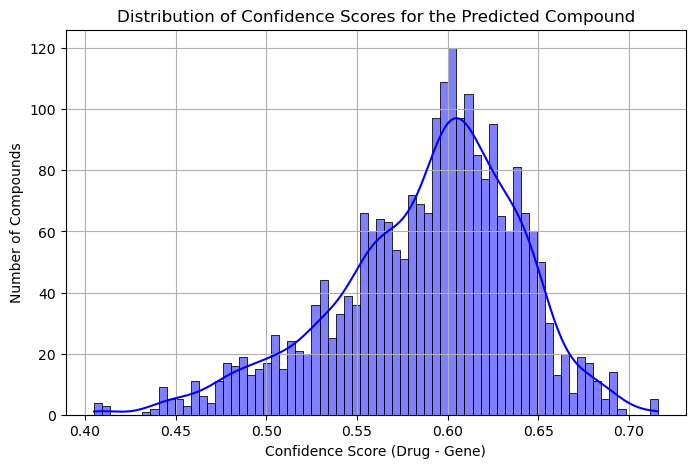

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plotting with seaborn for a more polished histogram
plt.figure(figsize=(8, 5)) # Cosine similarity
sns.histplot(df['cosine_distance'], bins=70, kde=True, color='blue')  # KDE adds a density curve
plt.title('Distribution of Confidence Scores for the Predicted Compound')
plt.xlabel('Confidence Score (Drug - Gene)')
plt.ylabel('Number of Compounds')
plt.grid(True)
# plt.savefig("./figures/novelgenes_compounds_top5_similarity_seminar_nov19.png", dpi=1000)
plt.show()

In [83]:
final_df.dropna(inplace=True)
final_df

,gene_name,compound_name,rank,cosine_distance,embedding_file
0,ACACB,MARAVIROC,1,0.4780,CPD-int-GEN
1,ACACB,SITAXSENTAN,2,0.4780,CPD-int-GEN
2,ACACB,1-(9-ETHYL-9H-CARBAZOL-3-YL)-N-METHYLMETHANAMINE,3,0.4776,CPD-int-GEN
3,ACACB,CLAZOSENTAN,4,0.4773,CPD-int-GEN
4,ACACB,NQDI-1,5,0.4771,CPD-int-GEN
...,...,...,...,...,...
1119,BEND6,"2-[(2-CHLORO-4-IODOPHENYL)AMINO]-N-{[(2R)-2,3-...",5,0.6054,CPD-int-GEN-cdp-GEN
1120,CPED1,[(1S)-1-(5-CHLORO-1-BENZOTHIEN-3-YL)-2-(2-NAPH...,1,0.5984,CPD-int-GEN-cdp-GEN
1121,CPED1,MENADIONE,2,0.5652,CPD-int-GEN-cdp-GEN
1122,CPED1,PYRIDOSTIGMINE,3,0.5649,CPD-int-GEN-cdp-GEN


In [ ]:
final_df.to_csv("~/rnaseq_synapse/novelgenes_compounds_top5_chemicals.csv")

Filtering by similarity threshold

In [1]:
import pandas as pd
df = pd.read_csv("~/rnaseq_synapse/novelgenes_compounds_top5_chemicals.csv", index_col=0)
df

,gene_name,compound_name,rank,cosine_distance,embedding_file
0,ACACB,MARAVIROC,1,0.4780,CPD-int-GEN
1,ACACB,SITAXSENTAN,2,0.4780,CPD-int-GEN
2,ACACB,1-(9-ETHYL-9H-CARBAZOL-3-YL)-N-METHYLMETHANAMINE,3,0.4776,CPD-int-GEN
3,ACACB,CLAZOSENTAN,4,0.4773,CPD-int-GEN
4,ACACB,NQDI-1,5,0.4771,CPD-int-GEN
...,...,...,...,...,...
1119,BEND6,"2-[(2-CHLORO-4-IODOPHENYL)AMINO]-N-{[(2R)-2,3-...",5,0.6054,CPD-int-GEN-cdp-GEN
1120,CPED1,[(1S)-1-(5-CHLORO-1-BENZOTHIEN-3-YL)-2-(2-NAPH...,1,0.5984,CPD-int-GEN-cdp-GEN
1121,CPED1,MENADIONE,2,0.5652,CPD-int-GEN-cdp-GEN
1122,CPED1,PYRIDOSTIGMINE,3,0.5649,CPD-int-GEN-cdp-GEN


In [9]:
# Count the occurrences of each compound
compound_counts = df['compound_name'].value_counts()

# Filter for compounds that appear more than twice
compounds_more_than_two = compound_counts[compound_counts >= 2]

# Print the compounds and their counts
print(compounds_more_than_two)

compound_name
CHEMBL351631                                                 5
PYRANTEL                                                     5
7-HYDROXY-2-OXO-CHROMENE-3-CARBOXYLIC ACID ETHYL ESTER       5
BUMETANIDE                                                   5
N-METHYL-N-[(1R)-1-METHYL-2-PHENYLETHYL]PROP-2-EN-1-AMINE    5
                                                            ..
(S)-MCPG                                                     2
SYNVISC                                                      2
GLYCODIAZINE                                                 2
LUSUTROMBOPAG                                                2
LEVOSIMENDAN                                                 2
Name: count, Length: 418, dtype: int64


In [10]:
# Further filter for cosine similarity greater than 0.65
fil_df = df[df['cosine_distance'] >= 0.65]
fil_df

,gene_name,compound_name,rank,cosine_distance,embedding_file
90,CPNE9,"4-(5-BENZO(1,3)DIOXOL-5-YL-4-PYRIDIN-2-YL-1H-I...",1,0.6662,CPD-int-GEN-cdp-GEN
91,CPNE9,BIRINAPANT,2,0.6654,CPD-int-GEN-cdp-GEN
92,CPNE9,NAPHTHYRIDINE INHIBITOR,3,0.6653,CPD-int-GEN-cdp-GEN
93,CPNE9,N-[4-(5-FLUORO-6-METHYLPYRIDIN-2-YL)-5-QUINOXA...,4,0.6651,CPD-int-GEN-cdp-GEN
94,CPNE9,"6-(3-AMINOPROPYL)-4,9-DIMETHYLPYRROLO[3,4-C]CA...",5,0.6643,CPD-int-GEN-cdp-GEN
...,...,...,...,...,...
704,SLC9A5,NEURACEQ,5,0.6650,CPD-int-GEN-ppi-GEN
775,TNFSF13B,METHYLTHIOADENOSINE,1,0.6582,CPD-int-GEN-ppi-GEN
776,TNFSF13B,284028-89-3,2,0.6567,CPD-int-GEN-ppi-GEN
777,TNFSF13B,(6-(4-(2-PIPERIDIN-1-YLETHOXY)PHENYL))-3-PYRID...,3,0.6544,CPD-int-GEN-ppi-GEN


In [11]:
print(fil_df['compound_name'].nunique())
print(fil_df['gene_name'].nunique())

165
44


In [12]:
print(df['compound_name'].value_counts())

compound_name
CHEMBL351631                                                                              5
PYRANTEL                                                                                  5
7-HYDROXY-2-OXO-CHROMENE-3-CARBOXYLIC ACID ETHYL ESTER                                    5
BUMETANIDE                                                                                5
N-METHYL-N-[(1R)-1-METHYL-2-PHENYLETHYL]PROP-2-EN-1-AMINE                                 5
                                                                                         ..
5-[4-(DIMETHYLAMINO)PHENYL]-6-[(6-MORPHOLIN-4-YLPYRIDIN-3-YL)ETHYNYL]PYRIMIDIN-4-AMINE    1
N-ACETYLHISTAMINE                                                                         1
S-(P-NITROBENZYL)GLUTATHIONE                                                              1
H TYPE II TRISACCHARIDE                                                                   1
2-[N'-(4-AMINO-BUTYL)-HYDRAZINOCARBONYL]-PYRROLIDINE-1-CARBOXYLIC 

In [5]:
# Filter the DataFrame to get compounds with cosine similarity greater than 0.65
high_similarity_compounds = df[df['cosine_distance'] >= 0.65]['compound_name']

# Count occurrences and filter for compounds that appear more than once
compound_counts = df['compound_name'].value_counts()
repeated_compounds = compound_counts[compound_counts > 1].index


# Convert both filters to sets and find the intersection
high_similarity_set = set(high_similarity_compounds)
repeated_compounds_set = set(repeated_compounds)

# Intersection of both sets
intersection_compounds = high_similarity_set.intersection(repeated_compounds_set)

# Print the result
print("Compounds with high similarity > 0.65 and repeated more than once:")
print(intersection_compounds)
print(len(intersection_compounds))

Compounds with high similarity > 0.65 and repeated more than once:
{'TERT-BUTYL ALCOHOL', 'DISOPYRAMIDE', "7-METHYL-GUANOSINE-5'-TRIPHOSPHATE-5'-GUANOSINE", 'N-AMINOETHYLMORPHOLINE', 'N-METHYL-N-[(1R)-1-METHYL-2-PHENYLETHYL]PROP-2-EN-1-AMINE', 'N-OXO-2-[(4-PHENYLPHENYL)SULFONYLAMINO]ETHANAMIDE', 'MOLPORT-039-101-288', 'N-OXO-2-(PHENYLSULFONYLAMINO)ETHANAMIDE', 'OR073698', 'PYRANTEL', 'SCHEMBL15421446', 'NICARDIPINE', 'PROMETHAZINE', '(3R)-3-HYDROXYMYRISTATE', 'PAGOCLONE', '1-BENZYLIMIDAZOLE'}
16


We retained 6 compounds out of this list which were FDA-approved drugs

In [ ]:
# List of the six drug names you're interested in
drug_list = ['DISOPYRAMIDE', 'PYRANTEL', 'NICARDIPINE', 'PROMETHAZINE', 'PAGOCLONE', '1-BENZYLIMIDAZOLE']

# Filter the DataFrame for rows where 'compound_name' is in drug_list
filtered_df = df[df["compound_name"].isin(drug_list)]

# # Count the number of matching rows
# num_rows = filtered_df.shape[0]
# print("Number of matching rows:", num_rows)
filtered_df


,gene_name,compound_name,rank,cosine_distance,embedding_file
13,AMZ1,PROMETHAZINE,4,0.5952,CPD-int-GEN-cdp-GEN
359,SLC22A6,PYRANTEL,5,0.5568,CPD-int-GEN-cdp-GEN
146,CFAP300,1-BENZYLIMIDAZOLE,2,0.6547,CPD-int-GEN-cex-GEN
265,EPS8,PYRANTEL,1,0.6252,CPD-int-GEN-cex-GEN
402,KCNH8,PROMETHAZINE,3,0.6667,CPD-int-GEN-cex-GEN
403,KCNH8,NICARDIPINE,4,0.6660,CPD-int-GEN-cex-GEN
729,SHISA6,PROMETHAZINE,5,0.5416,CPD-int-GEN-cex-GEN
866,VWA5B2,PYRANTEL,2,0.6250,CPD-int-GEN-cex-GEN
42,AHNAK,PYRANTEL,3,0.5490,CPD-int-GEN-ppi-GEN
161,CHST3,1-BENZYLIMIDAZOLE,2,0.6385,CPD-int-GEN-ppi-GEN


In [ ]:
import pandas as pd

# Assuming your DataFrame is already loaded into 'df'
# Group by compound_name and aggregate count and unique gene names
drug_info = filtered_df.groupby("compound_name").agg(
    num_rows=("gene_name", "size"),
    genes=("gene_name", lambda x: list(x.unique()))
).reset_index()

print(drug_info)


       compound_name  num_rows                                  genes
0  1-BENZYLIMIDAZOLE         2                       [CFAP300, CHST3]
1       DISOPYRAMIDE         3                [LRRTM1, SCN8A, SPTBN5]
2        NICARDIPINE         2                        [KCNH8, PDLIM5]
3          PAGOCLONE         2                        [MAN2A1, PAPLN]
4       PROMETHAZINE         3                  [AMZ1, KCNH8, SHISA6]
5           PYRANTEL         5  [SLC22A6, EPS8, VWA5B2, AHNAK, MAST1]


# Identification of Drug relations to pathways and molecular function (Biotque KG)

Input is the list of drugs. Three Different entities to be investigated

## 1. Pathways

In [ ]:
import pandas as pd

# Define the entities of interest
entity_interest = {'DISOPYRAMIDE', 'PYRANTEL', 'NICARDIPINE', 'PROMETHAZINE', 'PAGOCLONE', '1-BENZYLIMIDAZOLE'}
target_type = 'pathway'  # This can be 'gene' or 'disease' or any other entity
target_file = '/home/vmottaqi/rnaseq_synapse/Bioteque/PWY.tsv'  # Path to the target entity file

# Load data
embeddings = pd.read_csv('/home/vmottaqi/rnaseq_synapse/Bioteque/CPD-int-GEN-ass-PWY/embeddings/dists.tsv', sep='\t')
compounds = pd.read_csv('/home/vmottaqi/rnaseq_synapse/Bioteque/CPD.tsv', sep='\t')
targets = pd.read_csv(target_file, sep='\t')

# Map compounds and targets to their names
embeddings = embeddings.merge(compounds, left_on='n1_CPD', right_on='code', how='left')
embeddings = embeddings.merge(targets, left_on='n2_PWY', right_on='code', how='left')

# Rename columns for clarity
embeddings.rename(columns={'name_x': 'compound_name', 'name_y': f'{target_type}_name'}, inplace=True)

# Filter embeddings to only include items of interest
embeddings_filtered = embeddings[embeddings['compound_name'].isin(entity_interest)]

# Rank compounds for each target based on cosine similarity and select top 5
top_entities = embeddings_filtered.groupby('compound_name').apply(
    lambda x: x.nlargest(5, 'cosine_distance')
).reset_index(drop=True)

# Add a rank column
top_entities['rank'] = top_entities.groupby('compound_name').cumcount() + 1
top_entities['embedding_file'] = 'CPD-int-GEN-ass-PWY'  # Add a constant column with the same value

# Select and order the final columns
df1 = top_entities[['compound_name', f'{target_type}_name', 'rank', 'cosine_distance', 'embedding_file']]

# Display the DataFrame
df1


In [57]:
# Get the unique number of values in each of the first two columns
unique_diseases = df1.iloc[:, 0].nunique()
unique_compounds = df1.iloc[:, 1].nunique()

# Display the unique counts
print(f"Unique values in {df1.columns[0]}: {unique_diseases}")
print(f"Unique values in {df1.columns[1]}: {unique_compounds}")

# Check for values repeated more than once in the second column (compound_name)
repeated_compounds = df1.iloc[:, 1].value_counts()
repeated_compounds = repeated_compounds[repeated_compounds > 1]

# Display if there are repeated compounds and their counts
if not repeated_compounds.empty:
    print("pathways repeated more than once and their counts:")
    print(repeated_compounds)
else:
    print("No pathways are repeated more than once.")

Unique values in compound_name: 16
Unique values in pathway_name: 70
pathways repeated more than once and their counts:
pathway_name
Striated Muscle Contraction                 4
Glycogen breakdown (glycogenolysis)         3
Elastic fibre formation                     2
HuR (ELAVL1) binds and stabilizes mRNA      2
Protein methylation                         2
Molecules associated with elastic fibres    2
RHO GTPases activate PAKs                   2
Name: count, dtype: int64


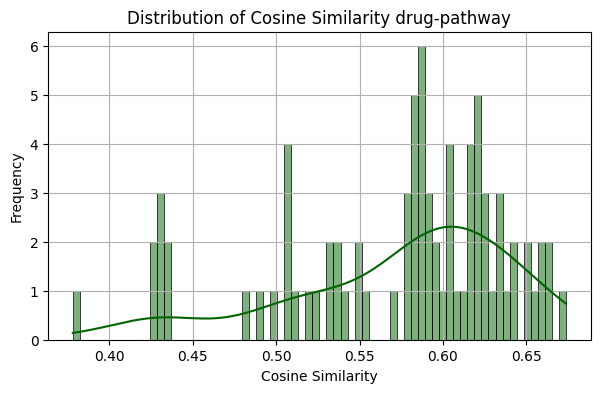

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plotting with seaborn for a more polished histogram
plt.figure(figsize=(7, 4))
sns.histplot(df1['cosine_distance'], bins=70, kde=True, color='darkgreen')  # KDE adds a density curve
plt.title('Distribution of Cosine Similarity drug-pathway')
plt.xlabel('Cosine Similarity')
plt.ylabel('Frequency')
plt.grid(True)
# plt.savefig("./figures/novelgenes_compounds_top5_similarity_nov4.png", dpi=1000)
plt.show()

In [58]:
df1.to_csv("/home/vmottaqi/rnaseq_synapse/interestcompounds_pathways.csv")

## 2. Molecular Function

In [ ]:
import pandas as pd

# Define the entities of interest
entity_interest = {'DISOPYRAMIDE', 'PYRANTEL', 'NICARDIPINE', 'PROMETHAZINE', 'PAGOCLONE', '1-BENZYLIMIDAZOLE'}
target_type = 'molecular function'  # This can be 'gene' or 'disease' or any other entity
target_file = '/home/vmottaqi/rnaseq_synapse/Bioteque/MFN.tsv'  # Path to the target entity file

# Load data
embeddings = pd.read_csv('/home/vmottaqi/rnaseq_synapse/Bioteque/CPD-int-GEN-has-MFN/embeddings/dists.tsv', sep='\t')
compounds = pd.read_csv('/home/vmottaqi/rnaseq_synapse/Bioteque/CPD.tsv', sep='\t')
targets = pd.read_csv(target_file, sep='\t')

# Map compounds and targets to their names
embeddings = embeddings.merge(compounds, left_on='n1_CPD', right_on='code', how='left')
embeddings = embeddings.merge(targets, left_on='n2_MFN', right_on='code', how='left')

# Rename columns for clarity
embeddings.rename(columns={'name_x': 'compound_name', 'name_y': f'{target_type}_name'}, inplace=True)

# Filter embeddings to only include items of interest
embeddings_filtered = embeddings[embeddings['compound_name'].isin(entity_interest)]

# Rank compounds for each target based on cosine similarity and select top 5
top_entities = embeddings_filtered.groupby('compound_name').apply(
    lambda x: x.nlargest(5, 'cosine_distance')
).reset_index(drop=True)

# Add a rank column
top_entities['rank'] = top_entities.groupby('compound_name').cumcount() + 1
top_entities['embedding_file'] = 'CPD-int-GEN-has-MFN'  # Add a constant column with the same value

# Select and order the final columns
df1 = top_entities[['compound_name', f'{target_type}_name', 'rank', 'cosine_distance', 'embedding_file']]


In [47]:
# Get the unique number of values in each of the first two columns
unique_diseases = df1.iloc[:, 0].nunique()
unique_compounds = df1.iloc[:, 1].nunique()

# Display the unique counts
print(f"Unique values in {df1.columns[0]}: {unique_diseases}")
print(f"Unique values in {df1.columns[1]}: {unique_compounds}")

# Check for values repeated more than once in the second column (compound_name)
repeated_compounds = df1.iloc[:, 1].value_counts()
repeated_compounds = repeated_compounds[repeated_compounds > 1]

# Display if there are repeated compounds and their counts
if not repeated_compounds.empty:
    print("MFN repeated more than once and their counts:")
    print(repeated_compounds)
else:
    print("MFN tissues are repeated more than once.")

Unique values in compound_name: 16
Unique values in molecular function_name: 72
MFN repeated more than once and their counts:
molecular function_name
hydrolase activity, acting on acid phosphorus-nitrogen bonds                       2
myosin binding                                                                     2
extracellular matrix constituent conferring elasticity                             2
structural molecule activity conferring elasticity                                 2
calcium-dependent protein serine/threonine phosphatase regulator activity          2
calcium-dependent protein kinase inhibitor activity                                2
RNA polymerase II transcription regulatory region sequence-specific DNA binding    2
serine-type endopeptidase activity                                                 2
Name: count, dtype: int64


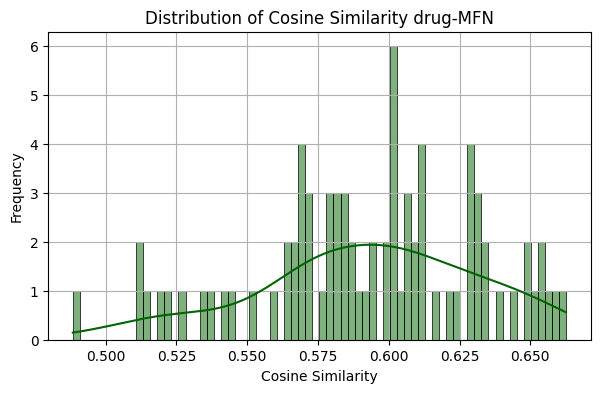

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plotting with seaborn for a more polished histogram
plt.figure(figsize=(7, 4))
sns.histplot(df1['cosine_distance'], bins=70, kde=True, color='darkgreen')  # KDE adds a density curve
plt.title('Distribution of Cosine Similarity drug-MFN')
plt.xlabel('Cosine Similarity')
plt.ylabel('Frequency')
plt.grid(True)
# plt.savefig("./figures/novelgenes_compounds_top5_similarity_nov4.png", dpi=1000)
plt.show()

In [63]:
df1.to_csv("/home/vmottaqi/rnaseq_synapse/interestcompounds_MFN.csv")

## 3. Cellular compartment

In [ ]:
import pandas as pd

# Define the entities of interest
entity_interest = {'DISOPYRAMIDE', 'PYRANTEL', 'NICARDIPINE', 'PROMETHAZINE', 'PAGOCLONE', '1-BENZYLIMIDAZOLE'}
target_type = 'Cellular compartments'  # This can be 'gene' or 'disease' or any other entity
target_file = '/home/vmottaqi/rnaseq_synapse/Bioteque/CMP.tsv'  # Path to the target entity file

# Load data
embeddings = pd.read_csv('/home/vmottaqi/rnaseq_synapse/Bioteque/CPD-int-GEN-has-CMP/embeddings/dists.tsv', sep='\t')
compounds = pd.read_csv('/home/vmottaqi/rnaseq_synapse/Bioteque/CPD.tsv', sep='\t')
targets = pd.read_csv(target_file, sep='\t')

# Map compounds and targets to their names
embeddings = embeddings.merge(compounds, left_on='n2_CPD', right_on='code', how='left')
embeddings = embeddings.merge(targets, left_on='n1_CMP', right_on='code', how='left')

# Rename columns for clarity
embeddings.rename(columns={'name_x': 'compound_name', 'name_y': f'{target_type}_name'}, inplace=True)

# Filter embeddings to only include items of interest
embeddings_filtered = embeddings[embeddings['compound_name'].isin(entity_interest)]

# Rank compounds for each target based on cosine similarity and select top 5
top_entities = embeddings_filtered.groupby('compound_name').apply(
    lambda x: x.nlargest(5, 'cosine_distance')
).reset_index(drop=True)

# Add a rank column
top_entities['rank'] = top_entities.groupby('compound_name').cumcount() + 1
top_entities['embedding_file'] = 'CPD-int-GEN-has-CMP'  # Add a constant column with the same value

# Select and order the final columns
df1 = top_entities[['compound_name', f'{target_type}_name', 'rank', 'cosine_distance', 'embedding_file']]


In [66]:
# Get the unique number of values in each of the first two columns
unique_diseases = df1.iloc[:, 0].nunique()
unique_compounds = df1.iloc[:, 1].nunique()

# Display the unique counts
print(f"Unique values in {df1.columns[0]}: {unique_diseases}")
print(f"Unique values in {df1.columns[1]}: {unique_compounds}")

# Check for values repeated more than once in the second column (compound_name)
repeated_compounds = df1.iloc[:, 1].value_counts()
repeated_compounds = repeated_compounds[repeated_compounds > 1]

# Display if there are repeated compounds and their counts
if not repeated_compounds.empty:
    print("CMP repeated more than once and their counts:")
    print(repeated_compounds)
else:
    print("CMP tissues are repeated more than once.")

Unique values in compound_name: 16
Unique values in Cellular compartments_name: 71
CMP repeated more than once and their counts:
Cellular compartments_name
U2-type catalytic step 2 spliceosome            3
cytoplasmic vesicle                             2
integral component of postsynaptic membrane     2
intrinsic component of postsynaptic membrane    2
integral component of synaptic membrane         2
intrinsic component of synaptic membrane        2
cholinergic synapse                             2
cardiac Troponin complex                        2
Name: count, dtype: int64


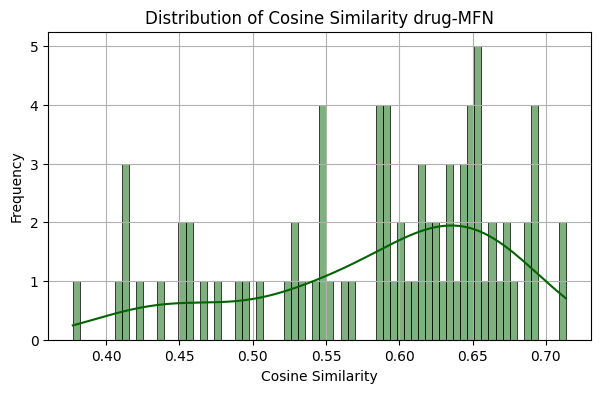

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plotting with seaborn for a more polished histogram
plt.figure(figsize=(7, 4))
sns.histplot(df1['cosine_distance'], bins=70, kde=True, color='darkgreen')  # KDE adds a density curve
plt.title('Distribution of Cosine Similarity drug-MFN')
plt.xlabel('Cosine Similarity')
plt.ylabel('Frequency')
plt.grid(True)
plt.savefig("./figures/novelgenes_compounds_top5_similarity_nov4.png", dpi=1000)
plt.show()

In [ ]:
df1.to_csv("/home/vmottaqi/rnaseq_synapse/interestcompounds_CMP.csv")